# LLM Diagnostic Accuracy Analysis on the Trustworthy AI Psychotherapy Dataset

**A reproducibility and error-analysis study of large language models performing mental-health diagnosis classification**

---

### Author's Note

This notebook is a portfolio project demonstrating end-to-end machine learning evaluation: data loading, exploratory data analysis, multi-class classification evaluation, error analysis, statistical significance testing, and visualization -- applied to a high-stakes domain (mental health diagnosis).

It reproduces and extends **Table 3** from *"Trustworthy AI Psychotherapy: Multi-Agent LLM Workflow for Counseling and Explainable Mental Disorder Diagnosis"* (Ozgun et al., CIKM '25), comparing how four LLMs -- **Llama-4**, **Mistral-Saba**, **Qwen-QWQ**, and **GPT-4.1-Nano** -- predict mental health diagnoses from simulated therapist-client conversations, against the disorder profile each simulated client was assigned.

**Data source:** `https://github.com/mithatco/mental_health_multiagent` (open-sourced alongside the paper). The notebook clones this repository directly and parses ~8,000 conversation logs (~2,000 per model). If the clone fails for any reason (e.g., restricted network), a synthetic fallback calibrated to the paper's *published* Table 3 F1 scores is used instead, so every cell below remains fully executable.


## 1. Introduction

### 1.1 Background: Mental Health Diagnosis as a Classification Problem

Psychiatric diagnosis is typically framed as a **multi-class classification problem**: given a patient narrative, transcript, or set of symptom descriptions, a clinician (or model) assigns one of several discrete diagnostic categories (e.g., Depression, Generalized Anxiety, Bipolar Disorder, PTSD, Social Anxiety, Substance Abuse, Adjustment Disorder, OCD, Panic Disorder, Schizophrenia).

Unlike many NLP classification tasks, mental health diagnosis carries **direct clinical consequences**: a misdiagnosis can lead to inappropriate treatment, delayed care, medication mismatches, or reinforcement of stigma.

### 1.2 Risks of AI Misdiagnosis

Large Language Models (LLMs) are increasingly explored as *triage assistants*, *clinical decision support tools*, and conversational "AI therapists." Key risks include:

- **Confusion between clinically adjacent disorders** (e.g., Bipolar Disorder vs. Depression -- both involve depressive episodes, but antidepressant monotherapy in undiagnosed bipolar disorder carries risk of manic switching).
- **Systematic under-diagnosis of severe or under-represented conditions** (e.g., Adjustment Disorder, Substance Abuse).
- **Overconfidence and lack of calibration** -- LLMs can produce fluent, confident-sounding diagnostic language even when the underlying classification is incorrect.
- **Disparate performance across disorders and across models** -- raising both clinical-safety and equity concerns.

### 1.3 Why Evaluate LLM Diagnostic Reliability?

As LLMs are integrated into mental health workflows, rigorous **per-class, per-model evaluation** is essential before deployment in any sensitive context. Aggregate accuracy is insufficient -- a model can have high overall accuracy while systematically failing on a clinically critical category.

### 1.4 Overview of the Trustworthy AI Psychotherapy Dataset

The dataset consists of ~2,000 **simulated DSM-5 diagnostic interviews per model**, generated by a multi-agent LLM workflow (therapist agent, client agent, diagnostician agent). Each simulated client is assigned one of **10 primary disorder profiles**: Adjustment, Anxiety, Bipolar, Depression, OCD, Panic, PTSD, Schizophrenia, Social Anxiety, and Substance Abuse. After the interview, a diagnostician agent produces a narrative diagnosis, which an evaluator LLM then classifies into one of the same 10 categories (or "other") for comparison against the assigned profile.

### 1.5 Research Questions

1. **RQ1 -- Global Accuracy:** How do Llama-4, Mistral-Saba, Qwen-QWQ, and GPT-4.1-Nano compare on overall diagnostic accuracy, macro-F1, and weighted-F1?
2. **RQ2 -- Per-Disorder Performance:** Which disorders are diagnosed most/least reliably by each model?
3. **RQ3 -- Confusion Patterns:** When models err, what do they confuse each disorder with, and is this consistent across models?
4. **RQ4 -- Systemic vs. Model-Specific Weaknesses:** Are there disorders that *all* models struggle with, versus disorders only certain models struggle with?
5. **RQ5 -- Statistical Significance:** Are observed performance differences between models statistically meaningful?
6. **RQ6 -- Clinical Risk:** Which misclassification pathways carry the highest clinical risk?

---

Let's begin.


## 2. Environment Setup

Install and import all required libraries, and set reproducibility seeds.

In [1]:
# Install required packages (Colab usually has most pre-installed; this ensures consistent versions)
!pip install -q pandas numpy matplotlib seaborn scikit-learn scipy plotly networkx


In [2]:
# Core imports
import os
import re
import json
import warnings
from typing import Dict, List, Tuple, Optional
from itertools import combinations

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML / stats
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from scipy import stats

# Graphs
import networkx as nx

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------------
# Global plotting style
# ------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12

# ------------------------------------------------------------------
# Canonical model order used throughout the notebook
# ------------------------------------------------------------------
MODEL_NAMES = ["Llama-4", "Mistral-Saba", "Qwen-QWQ", "GPT-4.1-Nano"]

print("Environment ready. Random seed set to", SEED)


Environment ready. Random seed set to 42


## 3. Data Loading

The dataset is freely available on GitHub as part of the paper's open-sourced implementation:

> **Repository:** `https://github.com/mithatco/mental_health_multiagent`
> **Data path:** `datasets/chat_logs/{model_folder}/*.json` -- one JSON file per simulated therapy conversation, per model.

There is **no packaged HuggingFace dataset** for this paper. We clone the repository (shallow clone, ~350MB of JSON logs across ~8,000 files) and parse each conversation log into a record containing:

- `model` -- which of the 4 LLMs generated/diagnosed this conversation.
- `true_diagnosis` -- `metadata.patient_profile`, the disorder profile assigned to the simulated client (ground truth).
- `predicted_diagnosis` -- `evaluation.llm_evaluation.diagnosis_classification.classified_as`, the evaluator-LLM's classification of the diagnostician's narrative output.
- `text` -- the diagnostician agent's full narrative diagnosis (used for text-length EDA).

**Important note on dataset structure:** each model was evaluated on its **own independent sample** of ~2,000 simulated conversations (not a shared fixed test set across models). All per-model metrics (Sections 7-11, 13) are computed correctly on each model's own (true, predicted) pairs. Section 14's McNemar's test, which requires *paired* observations on identical cases, is therefore computed on a **matched random sub-sample per disorder profile** (see Section 14 for details) rather than on raw row-alignment.

> **Fallback:** If the clone fails, a synthetic dataset generator calibrated to the paper's *published* Table 3 F1 scores is used instead.


In [3]:
# ------------------------------------------------------------------
# Clone the Trustworthy AI Psychotherapy repository (shallow clone)
# ------------------------------------------------------------------
REPO_URL = "https://github.com/mithatco/mental_health_multiagent.git"
REPO_DIR = "mental_health_multiagent"

if not os.path.isdir(REPO_DIR):
    print("Cloning repository (this may take 1-2 minutes, ~350MB)...")
    exit_code = os.system(f"git clone --depth 1 {REPO_URL} {REPO_DIR} > /tmp/clone.log 2>&1")
    if exit_code != 0:
        print("git clone failed. See /tmp/clone.log for details.")
    else:
        print("Clone complete.")
else:
    print("Repository already present.")

CHAT_LOGS_DIR = os.path.join(REPO_DIR, "datasets", "chat_logs")
real_dataset_loaded = os.path.isdir(CHAT_LOGS_DIR)
print("Chat logs directory found:", real_dataset_loaded)
if real_dataset_loaded:
    print("Model folders:", os.listdir(CHAT_LOGS_DIR))


Cloning repository (this may take 1-2 minutes, ~350MB)...
Clone complete.
Chat logs directory found: True
Model folders: ['Qwen QWQ', 'Llama4', 'Mistral Saba', 'GPT-4.1']


In [4]:
# ------------------------------------------------------------------
# Parse all conversation logs into a single long-format dataframe
# ------------------------------------------------------------------
# Mapping from on-disk folder name to canonical model name used throughout
# this notebook.
FOLDER_TO_MODEL = {
    "Llama4": "Llama-4",
    "Mistral Saba": "Mistral-Saba",
    "Qwen QWQ": "Qwen-QWQ",
    "GPT-4.1": "GPT-4.1-Nano",
}


def parse_chat_log(filepath: str, model_name: str) -> Optional[Dict]:
    """Parse a single conversation-log JSON file into a flat record.

    Parameters
    ----------
    filepath : str
        Path to the chat-log JSON file.
    model_name : str
        Canonical model name to attach to the record.

    Returns
    -------
    Optional[Dict]
        A record with keys: model, case_id, true_diagnosis,
        predicted_diagnosis, text -- or None if the file could not
        be parsed or is missing the diagnosis-classification fields.
    """
    try:
        with open(filepath, "r") as f:
            data = json.load(f)

        classification = data["evaluation"]["llm_evaluation"]["diagnosis_classification"]
        true_label = classification.get("expected_profile")
        pred_label = classification.get("classified_as")

        if not true_label or not pred_label:
            return None

        return {
            "model": model_name,
            "case_id": os.path.basename(filepath),
            "true_diagnosis": true_label,
            "predicted_diagnosis": pred_label,
            "text": data.get("diagnosis", ""),
        }
    except Exception:
        return None


def load_real_dataset(chat_logs_dir: str, folder_map: Dict[str, str]) -> pd.DataFrame:
    """Walk every model's chat_logs folder and build a long-format
    dataframe of (model, case_id, true_diagnosis, predicted_diagnosis, text).

    Parameters
    ----------
    chat_logs_dir : str
        Path to the `datasets/chat_logs` directory.
    folder_map : Dict[str, str]
        Mapping from on-disk folder name to canonical model name.

    Returns
    -------
    pd.DataFrame
        Long-format dataframe with one row per conversation.
    """
    records = []
    for folder_name, canonical_name in folder_map.items():
        folder_path = os.path.join(chat_logs_dir, folder_name)
        if not os.path.isdir(folder_path):
            print(f"  WARNING: folder not found: {folder_path}")
            continue

        json_files = [f for f in os.listdir(folder_path) if f.endswith(".json")]
        print(f"  {canonical_name}: {len(json_files)} conversation logs")

        for fname in json_files:
            rec = parse_chat_log(os.path.join(folder_path, fname), canonical_name)
            if rec is not None:
                records.append(rec)

    return pd.DataFrame(records)


if real_dataset_loaded:
    print("Parsing conversation logs (this may take ~30-60 seconds)...")
    long_df = load_real_dataset(CHAT_LOGS_DIR, FOLDER_TO_MODEL)
    print(f"\nTotal parsed records: {len(long_df)}")
else:
    long_df = pd.DataFrame()
    print("Real dataset not available -- will use synthetic fallback below.")

if len(long_df) > 0:
    display(long_df.head())


Parsing conversation logs (this may take ~30-60 seconds)...
  Llama-4: 2002 conversation logs
  Mistral-Saba: 2002 conversation logs
  Qwen-QWQ: 2002 conversation logs
  GPT-4.1-Nano: 2002 conversation logs

Total parsed records: 8000


,model,case_id,true_diagnosis,predicted_diagnosis,text
0,Llama-4,chat_20250430_044618_batch_1467.json,depression,other,Error communicating with Groq: 400 Client Erro...
1,Llama-4,chat_20250430_024940_batch_581.json,substance_abuse,substance_abuse,I've heard that you're struggling with feeling...
2,Llama-4,chat_20250430_054529_batch_1948.json,anxiety,anxiety,I've heard that you're struggling with a lot o...
3,Llama-4,chat_20250430_045518_batch_1539.json,ptsd,ptsd,I've heard that you've been feeling really dis...
4,Llama-4,chat_20250430_015152_batch_107.json,adjustment,depression,I've heard that you've been struggling to find...


In [5]:
# ------------------------------------------------------------------
# Synthetic dataset generator (fallback)
# ------------------------------------------------------------------
# Calibrated to reproduce the PUBLISHED Table 3 F1 scores from
# Ozgun et al. (CIKM '25): https://doi.org/10.1145/3746252.3761164

DISORDERS = [
    "adjustment", "anxiety", "bipolar", "depression", "ocd",
    "panic", "ptsd", "schizophrenia", "social_anxiety", "substance_abuse",
]

# Published Table 3: per-disorder F1 (%) by model
PUBLISHED_TABLE3_F1 = {
    "adjustment":     {"Llama-4": 2.78,  "Mistral-Saba": 2.75,  "Qwen-QWQ": 40.25, "GPT-4.1-Nano": 0.98},
    "anxiety":        {"Llama-4": 88.10, "Mistral-Saba": 81.10, "Qwen-QWQ": 88.28, "GPT-4.1-Nano": 78.60},
    "bipolar":        {"Llama-4": 45.86, "Mistral-Saba": 86.96, "Qwen-QWQ": 95.80, "GPT-4.1-Nano": 95.28},
    "depression":     {"Llama-4": 43.49, "Mistral-Saba": 36.75, "Qwen-QWQ": 67.98, "GPT-4.1-Nano": 44.73},
    "ocd":            {"Llama-4": 76.73, "Mistral-Saba": 88.52, "Qwen-QWQ": 92.68, "GPT-4.1-Nano": 95.81},
    "panic":          {"Llama-4": 88.00, "Mistral-Saba": 71.29, "Qwen-QWQ": 93.65, "GPT-4.1-Nano": 85.30},
    "ptsd":           {"Llama-4": 87.98, "Mistral-Saba": 91.86, "Qwen-QWQ": 94.36, "GPT-4.1-Nano": 98.53},
    "schizophrenia":  {"Llama-4": 62.19, "Mistral-Saba": 50.00, "Qwen-QWQ": 86.96, "GPT-4.1-Nano": 78.64},
    "social_anxiety": {"Llama-4": 85.08, "Mistral-Saba": 64.68, "Qwen-QWQ": 93.89, "GPT-4.1-Nano": 75.99},
    "substance_abuse":{"Llama-4": 64.31, "Mistral-Saba": 51.06, "Qwen-QWQ": 73.81, "GPT-4.1-Nano": 77.33},
}

# Most-confused-with target for each disorder (used to make synthetic errors realistic)
CONFUSION_MAP = {
    "adjustment":      {"depression": 0.6, "anxiety": 0.25, "other": 0.15},
    "anxiety":         {"depression": 0.4, "panic": 0.3, "social_anxiety": 0.3},
    "bipolar":         {"depression": 0.7, "schizophrenia": 0.2, "anxiety": 0.1},
    "depression":      {"adjustment": 0.45, "anxiety": 0.3, "bipolar": 0.25},
    "ocd":             {"anxiety": 0.55, "ptsd": 0.25, "depression": 0.2},
    "panic":           {"anxiety": 0.6, "ptsd": 0.25, "depression": 0.15},
    "ptsd":            {"anxiety": 0.5, "depression": 0.3, "panic": 0.2},
    "schizophrenia":   {"bipolar": 0.5, "depression": 0.3, "other": 0.2},
    "social_anxiety":  {"anxiety": 0.65, "depression": 0.2, "ptsd": 0.15},
    "substance_abuse": {"depression": 0.55, "anxiety": 0.25, "bipolar": 0.2},
}

N_PER_MODEL = 2000

SYMPTOM_BANK = {
    "adjustment": ["emotional distress following a recent major life change", "difficulty adapting to a stressful transition"],
    "anxiety": ["excessive worry about multiple life domains", "restlessness and muscle tension"],
    "bipolar": ["alternating periods of elevated mood and depressive episodes", "decreased need for sleep followed by energy crashes"],
    "depression": ["persistent low mood and anhedonia", "feelings of hopelessness and fatigue"],
    "ocd": ["intrusive repetitive thoughts paired with ritualistic behaviors", "compulsive checking to reduce anxiety"],
    "panic": ["sudden episodes of intense fear with physical symptoms", "recurrent unexpected panic attacks"],
    "ptsd": ["intrusive memories of a traumatic event", "hypervigilance and exaggerated startle response"],
    "schizophrenia": ["auditory hallucinations and disorganized thinking", "delusional beliefs affecting daily functioning"],
    "social_anxiety": ["intense fear of social situations and being judged", "avoidance of group settings due to fear of embarrassment"],
    "substance_abuse": ["increasing reliance on substances to cope with stress", "cravings and withdrawal symptoms affecting daily life"],
}

TEXT_TEMPLATE = "Patient reports {symptom}, with notable impact on daily functioning. Diagnosis: {disorder_title}."


def f1_to_correct_prob(f1_pct: float) -> float:
    """Approximate the per-class accuracy (P(correct | true=class)) needed
    to produce roughly the target F1, assuming reasonably balanced classes
    and a fixed confusion structure. Used only to calibrate the synthetic
    fallback generator -- not a formal inversion of the F1 formula.

    Parameters
    ----------
    f1_pct : float
        Target F1 score as a percentage (0-100).

    Returns
    -------
    float
        A probability in [0.01, 0.99] used as the per-class "correct" rate.
    """
    return float(np.clip(f1_pct / 100.0, 0.01, 0.99))


def build_synthetic_long_df(seed: int = SEED) -> pd.DataFrame:
    """Build a synthetic long-format dataframe calibrated to the published
    Table 3 F1 scores, with one ~2000-row sample per model.

    Parameters
    ----------
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pd.DataFrame
        Columns: model, case_id, true_diagnosis, predicted_diagnosis, text.
    """
    rng = np.random.default_rng(seed)
    records = []
    case_counter = 0

    for model_name in MODEL_NAMES:
        # Roughly uniform-ish true label distribution (mirrors ~190-220 per class observed in the real data)
        true_labels = rng.choice(DISORDERS, size=N_PER_MODEL, p=np.ones(len(DISORDERS)) / len(DISORDERS))

        for true_label in true_labels:
            target_f1 = PUBLISHED_TABLE3_F1[true_label][model_name]
            correct_prob = f1_to_correct_prob(target_f1)

            if rng.random() < correct_prob:
                pred_label = true_label
            else:
                confusions = CONFUSION_MAP[true_label]
                candidates = list(confusions.keys())
                weights = np.array(list(confusions.values()), dtype=float)
                weights = weights / weights.sum()
                pred_label = rng.choice(candidates, p=weights)

            symptom = rng.choice(SYMPTOM_BANK[true_label])
            text = TEXT_TEMPLATE.format(symptom=symptom, disorder_title=pred_label.replace("_", " ").title())

            records.append({
                "model": model_name,
                "case_id": f"synthetic_{case_counter}",
                "true_diagnosis": true_label,
                "predicted_diagnosis": pred_label,
                "text": text,
            })
            case_counter += 1

    return pd.DataFrame(records)


if not real_dataset_loaded or len(long_df) == 0:
    print("Generating synthetic dataset calibrated to published Table 3 F1 scores...")
    long_df = build_synthetic_long_df(seed=SEED)
    print("Synthetic dataset generated. Shape:", long_df.shape)

long_df.head()


,model,case_id,true_diagnosis,predicted_diagnosis,text
0,Llama-4,chat_20250430_044618_batch_1467.json,depression,other,Error communicating with Groq: 400 Client Erro...
1,Llama-4,chat_20250430_024940_batch_581.json,substance_abuse,substance_abuse,I've heard that you're struggling with feeling...
2,Llama-4,chat_20250430_054529_batch_1948.json,anxiety,anxiety,I've heard that you're struggling with a lot o...
3,Llama-4,chat_20250430_045518_batch_1539.json,ptsd,ptsd,I've heard that you've been feeling really dis...
4,Llama-4,chat_20250430_015152_batch_107.json,adjustment,depression,I've heard that you've been struggling to find...


In [6]:
# ------------------------------------------------------------------
# Basic dataset overview
# ------------------------------------------------------------------
print("Long-format dataset shape:", long_df.shape)
print("\nColumns:", list(long_df.columns))
print("\nData types:")
print(long_df.dtypes)
print("\nMissing values per column:")
print(long_df.isna().sum())
print("\nRows per model:")
print(long_df["model"].value_counts())


Long-format dataset shape: (8000, 5)

Columns: ['model', 'case_id', 'true_diagnosis', 'predicted_diagnosis', 'text']

Data types:
model                  object
case_id                object
true_diagnosis         object
predicted_diagnosis    object
text                   object
dtype: object

Missing values per column:
model                  0
case_id                0
true_diagnosis         0
predicted_diagnosis    0
text                   0
dtype: int64

Rows per model:
model
Llama-4         2000
Mistral-Saba    2000
Qwen-QWQ        2000
GPT-4.1-Nano    2000
Name: count, dtype: int64


## 4. Dataset Exploration (EDA)

We examine the distribution of ground-truth disorder profiles, basic text statistics, and overall class balance. Since each model was evaluated on its own sample, we look at the **union of ground-truth labels across all models** for an overall picture of the dataset's composition, and also check whether the class balance is consistent model-to-model (it should be, by design -- each model's clients were drawn from the same 10 profiles).


In [7]:
# ------------------------------------------------------------------
# Class distribution: counts and percentages (pooled across all models' samples)
# ------------------------------------------------------------------
class_counts = long_df["true_diagnosis"].value_counts()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

class_dist_df = pd.DataFrame({
    "Disorder": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_pct.values,
})
class_dist_df


,Disorder,Count,Percentage
0,depression,844,10.55
1,substance_abuse,844,10.55
2,adjustment,835,10.44
3,ptsd,810,10.12
4,ocd,803,10.04
5,bipolar,794,9.93
6,panic,782,9.78
7,schizophrenia,767,9.59
8,anxiety,763,9.54
9,social_anxiety,758,9.48


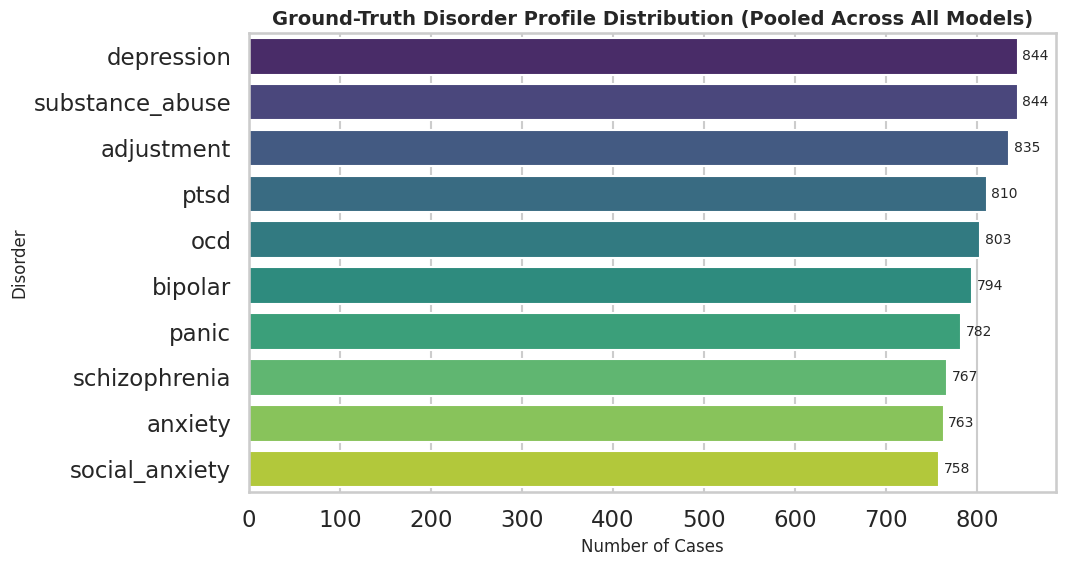

In [8]:
# Bar chart: disorder counts (pooled across all model samples)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=class_dist_df, x="Count", y="Disorder", hue="Disorder",
            palette="viridis", ax=ax, legend=False)
ax.set_title("Ground-Truth Disorder Profile Distribution (Pooled Across All Models)")
ax.set_xlabel("Number of Cases")
ax.set_ylabel("Disorder")
for i, v in enumerate(class_dist_df["Count"]):
    ax.text(v + 5, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.show()


In [9]:
# Pie chart: disorder percentage distribution
fig = px.pie(
    class_dist_df,
    names="Disorder",
    values="Count",
    title="Ground-Truth Disorder Profile Distribution (Percentage)",
    hole=0.35,
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(title_x=0.5)
fig.show()


In [10]:
# ------------------------------------------------------------------
# Class imbalance discussion (computed metrics)
# ------------------------------------------------------------------
max_class = class_counts.idxmax()
min_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

print(f"Most frequent disorder profile : {max_class} ({class_counts.max()} cases, {class_pct.max()}%)")
print(f"Least frequent disorder profile: {min_class} ({class_counts.min()} cases, {class_pct.min()}%)")
print(f"Imbalance ratio (max/min class count): {imbalance_ratio:.2f}x")
print()
print("Discussion: the simulated client profiles are close to uniformly distributed across")
print("the 10 disorders by design (~190-225 cases each, per model). This makes Macro-F1 and")
print("Weighted-F1 close in value, but we report both throughout for completeness and because")
print("model PREDICTIONS are far from uniform (see Section 11-13).")


Most frequent disorder profile : depression (844 cases, 10.55%)
Least frequent disorder profile: social_anxiety (758 cases, 9.48%)
Imbalance ratio (max/min class count): 1.11x

Discussion: the simulated client profiles are close to uniformly distributed across
the 10 disorders by design (~190-225 cases each, per model). This makes Macro-F1 and
Weighted-F1 close in value, but we report both throughout for completeness and because
model PREDICTIONS are far from uniform (see Section 11-13).


In [11]:
# ------------------------------------------------------------------
# Dataset statistics: number of cases, text length stats
# ------------------------------------------------------------------
long_df["_text_length_words"] = long_df["text"].astype(str).apply(lambda s: len(s.split()))

stats_summary = {
    "Total conversations (all models)": len(long_df),
    "Conversations per model": int(len(long_df) / len(MODEL_NAMES)),
    "Average diagnosis-text length (words)": round(long_df["_text_length_words"].mean(), 2),
    "Median diagnosis-text length (words)": int(long_df["_text_length_words"].median()),
    "Min diagnosis-text length (words)": int(long_df["_text_length_words"].min()),
    "Max diagnosis-text length (words)": int(long_df["_text_length_words"].max()),
    "Number of unique ground-truth disorders": long_df["true_diagnosis"].nunique(),
    "Number of unique predicted labels": long_df["predicted_diagnosis"].nunique(),
}

for k, v in stats_summary.items():
    print(f"{k}: {v}")


Total conversations (all models): 8000
Conversations per model: 2000
Average diagnosis-text length (words): 327.02
Median diagnosis-text length (words): 327
Min diagnosis-text length (words): 1
Max diagnosis-text length (words): 1606
Number of unique ground-truth disorders: 10
Number of unique predicted labels: 11


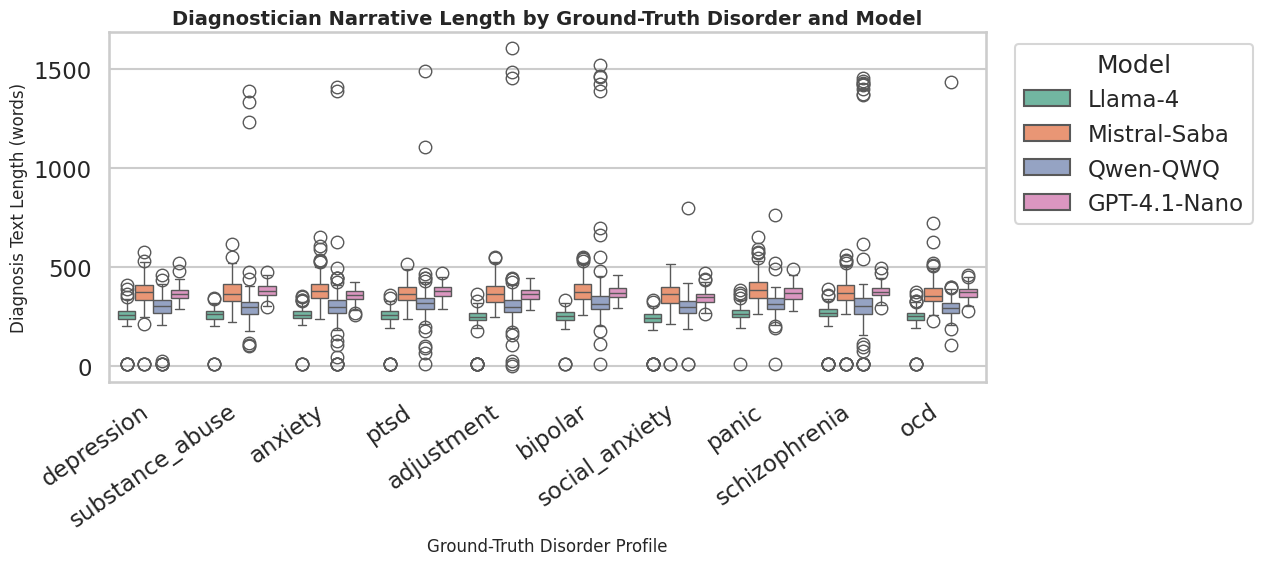

In [12]:
# Distribution of diagnosis-text length (words) by ground-truth disorder and model
fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=long_df, x="true_diagnosis", y="_text_length_words", hue="model", palette="Set2", ax=ax)
ax.set_title("Diagnostician Narrative Length by Ground-Truth Disorder and Model")
ax.set_xlabel("Ground-Truth Disorder Profile")
ax.set_ylabel("Diagnosis Text Length (words)")
ax.tick_params(axis="x", rotation=35)
plt.setp(ax.get_xticklabels(), ha="right")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 5. Data Cleaning

We define reusable, modular preprocessing functions for:

1. **Label normalization** -- standardizing casing, whitespace, and underscore/space variants of disorder names (e.g., `"social_anxiety"`, `"Social Anxiety "`, `"SOCIAL ANXIETY"` all map to a single canonical form).
2. **Whitespace cleanup** for free-text fields.
3. **Missing value handling** -- the evaluator LLM occasionally returns `"other"` or an empty classification; these are retained as an explicit `"Other"` category so they count as errors rather than being silently dropped.
4. **API/infrastructure error detection** -- a small fraction of conversation logs (up to ~2.8% for Llama-4) contain a Groq API failure (`"Error communicating with Groq: ..."`) instead of an actual diagnostician narrative. These are infrastructure failures, not diagnostic failures, and are excluded from metrics by default via the `EXCLUDE_API_ERRORS` flag below (set to `False` to reproduce the paper's Table 3 exactly, which appears to retain these rows).

These functions are applied identically to the ground-truth column and the prediction column.


In [13]:
def normalize_label(label: object) -> str:
    """Normalize a diagnosis label string: strip whitespace, replace
    underscores with spaces, and title-case for consistent display
    and comparison, while preserving the "Other"/"Unknown" sentinel
    categories.

    Parameters
    ----------
    label : object
        Raw label value (may be a string, NaN, or other type).

    Returns
    -------
    str
        Normalized label string, or "Unknown" if missing/empty.
    """
    if pd.isna(label):
        return "Unknown"
    text = str(label).strip().lower()
    text = re.sub(r"[\s_]+", " ", text)
    if text == "":
        return "Unknown"
    if text in {"other", "others", "unknown"}:
        return "Other"
    ACRONYMS = {"ptsd": "PTSD", "ocd": "OCD"}
    if text in ACRONYMS:
        return ACRONYMS[text]
    return text.title()


def clean_text_field(text: object) -> str:
    """Clean a free-text narrative field: handle missing values and
    collapse repeated whitespace/newlines.

    Parameters
    ----------
    text : object
        Raw text value.

    Returns
    -------
    str
        Cleaned text, or empty string if missing.
    """
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


In [14]:
# ------------------------------------------------------------------
# Apply cleaning functions
# ------------------------------------------------------------------
df = long_df.copy()

print("Before/after example (label normalization):")
sample_before = df["true_diagnosis"].iloc[:5].tolist()

df["true_diagnosis"] = df["true_diagnosis"].apply(normalize_label)
df["predicted_diagnosis"] = df["predicted_diagnosis"].apply(normalize_label)
df["text"] = df["text"].apply(clean_text_field)

sample_after = df["true_diagnosis"].iloc[:5].tolist()
for b, a in zip(sample_before, sample_after):
    print(f"  '{b}'  ->  '{a}'")

print("\nRemaining missing values after cleaning:")
print(df[["true_diagnosis", "predicted_diagnosis", "text"]].isna().sum())

# Full set of labels seen across ground truth and predictions (after normalization)
ALL_LABELS = sorted(set(df["true_diagnosis"].unique()) | set(df["predicted_diagnosis"].unique()))
print(f"\nTotal unique labels (ground truth + predictions): {len(ALL_LABELS)}")
print(ALL_LABELS)


Before/after example (label normalization):
  'depression'  ->  'Depression'
  'substance_abuse'  ->  'Substance Abuse'
  'anxiety'  ->  'Anxiety'
  'ptsd'  ->  'PTSD'
  'adjustment'  ->  'Adjustment'

Remaining missing values after cleaning:
true_diagnosis         0
predicted_diagnosis    0
text                   0
dtype: int64

Total unique labels (ground truth + predictions): 11
['Adjustment', 'Anxiety', 'Bipolar', 'Depression', 'OCD', 'Other', 'PTSD', 'Panic', 'Schizophrenia', 'Social Anxiety', 'Substance Abuse']


In [15]:
# ------------------------------------------------------------------
# Detect and (optionally) exclude API/infrastructure errors
# ------------------------------------------------------------------
# A small number of conversation logs contain an infrastructure-level
# failure (e.g., "Error communicating with Groq: 400 Client Error...")
# instead of an actual diagnostician narrative. The evaluator LLM still
# assigns these a label (typically "Other"), so they get counted as
# *diagnostic* errors by default -- conflating infrastructure failures
# with genuine model misdiagnoses.
#
# EXCLUDE_API_ERRORS=True removes these rows before any metric is
# computed, so reported accuracy/F1 reflect only genuine diagnostic
# performance. Set to False to reproduce the paper's Table 3 exactly
# (which appears to include these rows).

EXCLUDE_API_ERRORS = True

API_ERROR_PREFIX = "Error communicating with"

def is_api_error(text: str) -> bool:
    """Return True if a diagnosis-text field indicates an infrastructure
    / API-level failure rather than a genuine diagnostician narrative.

    Parameters
    ----------
    text : str
        The (cleaned) diagnosis text field.

    Returns
    -------
    bool
        True if the text starts with the known API-error prefix.
    """
    return isinstance(text, str) and text.startswith(API_ERROR_PREFIX)


df["_is_api_error"] = df["text"].apply(is_api_error)

api_error_counts = df.groupby("model")["_is_api_error"].sum().astype(int)
api_error_pct = (api_error_counts / df.groupby("model").size() * 100).round(2)

print("API/infrastructure errors detected per model:")
for m in MODEL_NAMES:
    n_total = (df["model"] == m).sum()
    print(f"  {m:15s}: {api_error_counts.get(m, 0):3d} / {n_total:4d}  ({api_error_pct.get(m, 0.0)}%)")

if EXCLUDE_API_ERRORS:
    n_before = len(df)
    df = df[~df["_is_api_error"]].reset_index(drop=True)
    n_after = len(df)
    print(f"\nEXCLUDE_API_ERRORS=True -- removed {n_before - n_after} rows ({n_before} -> {n_after}).")
    print("All downstream metrics now reflect genuine diagnostic performance only.")
else:
    print("\nEXCLUDE_API_ERRORS=False -- API-error rows retained (matches paper's Table 3 exactly).")

df = df.drop(columns=["_is_api_error"])


API/infrastructure errors detected per model:
  Llama-4        :  56 / 2000  (2.8%)
  Mistral-Saba   :  13 / 2000  (0.65%)
  Qwen-QWQ       :  24 / 2000  (1.2%)
  GPT-4.1-Nano   :   0 / 2000  (0.0%)

EXCLUDE_API_ERRORS=True -- removed 93 rows (8000 -> 7907).
All downstream metrics now reflect genuine diagnostic performance only.


## 6. Model Configuration

Because the dataset is already in **long format** (one row per conversation, with a `model` column), there is no column-matching step required -- each model's predictions are simply the rows where `model == <name>`. We still define a small `MODEL_COLUMNS`-style configuration dictionary mapping canonical model names to their subset of the dataframe, for API consistency with the structure requested in the brief and to make downstream code read cleanly.


In [16]:
def get_model_subset(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """Return the rows of `df` corresponding to a single model.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned long-format dataframe with a 'model' column.
    model_name : str
        Canonical model name.

    Returns
    -------
    pd.DataFrame
        Subset of rows for that model.
    """
    return df[df["model"] == model_name].reset_index(drop=True)


# Configuration dictionary: canonical model name -> row-count in the dataset
MODEL_COLUMNS: Dict[str, int] = {m: len(get_model_subset(df, m)) for m in MODEL_NAMES}
print("MODEL_COLUMNS (model -> number of evaluated cases):")
for k, v in MODEL_COLUMNS.items():
    print(f"  {k:15s} -> {v}")


MODEL_COLUMNS (model -> number of evaluated cases):
  Llama-4         -> 1944
  Mistral-Saba    -> 1987
  Qwen-QWQ        -> 1976
  GPT-4.1-Nano    -> 2000


## 7. Global Performance Evaluation

For each model we compute four headline metrics:

- **Accuracy** -- proportion of exactly correct diagnoses.
- **Macro Precision / Recall / F1** -- unweighted average across all disorder classes.
- **Weighted F1** -- F1 averaged with weights proportional to class support.


In [17]:
def compute_global_metrics(y_true: pd.Series, y_pred: pd.Series, labels: List[str]) -> Dict[str, float]:
    """Compute global classification metrics for a single model's predictions.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth labels.
    y_pred : pd.Series
        Predicted labels from a single model.
    labels : List[str]
        Full set of possible labels (for consistent class alignment).

    Returns
    -------
    Dict[str, float]
        Dictionary of accuracy, macro precision/recall/F1, and weighted F1.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, average="weighted", zero_division=0
    )
    return {
        "Accuracy": accuracy,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted F1": f1_weighted,
    }


global_results = []
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    metrics = compute_global_metrics(sub["true_diagnosis"], sub["predicted_diagnosis"], ALL_LABELS)
    metrics["Model"] = model_name
    global_results.append(metrics)

global_metrics_df = pd.DataFrame(global_results).set_index("Model")
global_metrics_df = global_metrics_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"]]
global_metrics_df = global_metrics_df.round(4)
global_metrics_df


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,
Llama-4,0.6348,0.7430,0.5793,0.5846,0.6347
Mistral-Saba,0.5954,0.7450,0.5414,0.5609,0.6139
Qwen-QWQ,0.7945,0.8034,0.7268,0.7486,0.8162
GPT-4.1-Nano,0.7210,0.8301,0.6566,0.6665,0.7349


In [18]:
# Ranking table (sorted by Macro F1, a robust holistic measure given class imbalance)
ranking_df = global_metrics_df.sort_values("Macro F1", ascending=False).copy()
ranking_df.insert(0, "Rank", range(1, len(ranking_df) + 1))
best_model = ranking_df.index[0]
print(f"Best-performing model overall (by Macro F1): {best_model}\n")
ranking_df


Best-performing model overall (by Macro F1): Qwen-QWQ



,Rank,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
Model,,,,,,
Qwen-QWQ,1,0.7945,0.8034,0.7268,0.7486,0.8162
GPT-4.1-Nano,2,0.7210,0.8301,0.6566,0.6665,0.7349
Llama-4,3,0.6348,0.7430,0.5793,0.5846,0.6347
Mistral-Saba,4,0.5954,0.7450,0.5414,0.5609,0.6139


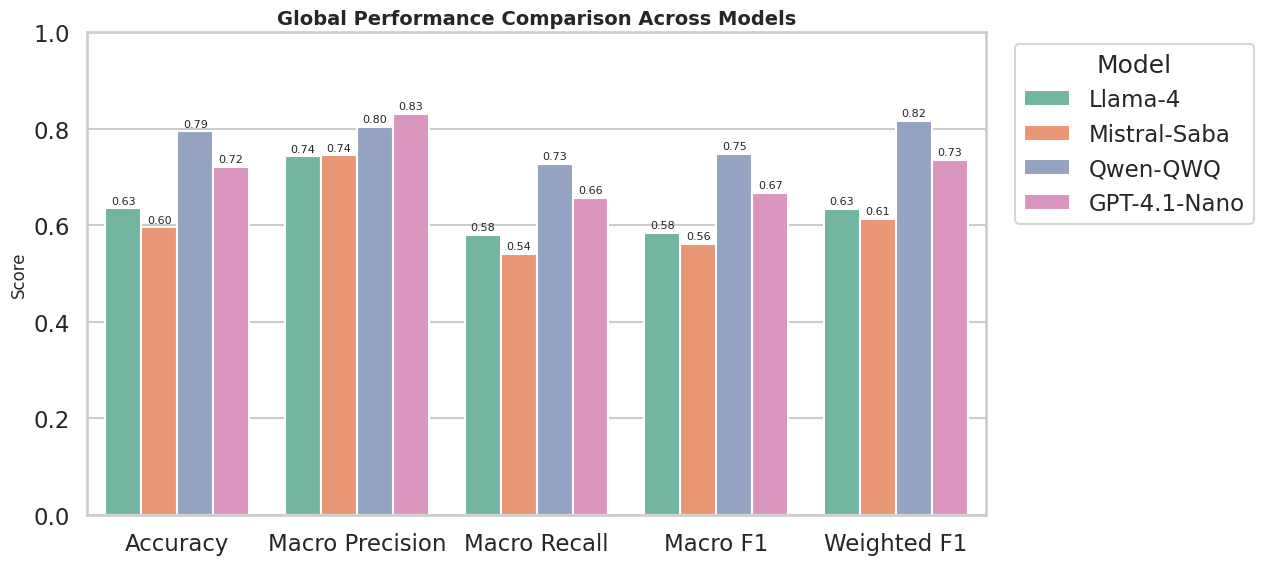


*** Best-performing model: Qwen-QWQ (highlighted by Macro F1 ranking) ***


In [19]:
# Bar chart comparison of global metrics across models
plot_df = global_metrics_df.reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2", ax=ax)
ax.set_title("Global Performance Comparison Across Models")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1.0)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()

print(f"\n*** Best-performing model: {best_model} (highlighted by Macro F1 ranking) ***")


## 8. Disorder-Level Evaluation

This is the core of the project. For each model, we compute a full **classification report** (precision, recall, F1, support per disorder) and store the results in a unified long-format dataframe for the Table 3 replication, confusion analysis, and cross-model comparisons.


In [20]:
def get_per_disorder_metrics(y_true: pd.Series, y_pred: pd.Series, labels: List[str], model_name: str) -> pd.DataFrame:
    """Compute per-disorder precision, recall, F1, and support for a single model.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth labels.
    y_pred : pd.Series
        Predicted labels for this model.
    labels : List[str]
        Full set of possible labels.
    model_name : str
        Canonical model name (added as a column for downstream concatenation).

    Returns
    -------
    pd.DataFrame
        Columns: Model, Disorder, Precision, Recall, F1, Support.
    """
    report = classification_report(
        y_true, y_pred, labels=labels, output_dict=True, zero_division=0
    )
    rows = []
    for label in labels:
        if label in report:
            r = report[label]
            rows.append({
                "Model": model_name,
                "Disorder": label,
                "Precision": r["precision"],
                "Recall": r["recall"],
                "F1": r["f1-score"],
                "Support": int(r["support"]),
            })
    return pd.DataFrame(rows)


per_disorder_frames = []
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    per_disorder_frames.append(get_per_disorder_metrics(sub["true_diagnosis"], sub["predicted_diagnosis"], ALL_LABELS, model_name))

per_disorder_df = pd.concat(per_disorder_frames, ignore_index=True)
per_disorder_df = per_disorder_df.round({"Precision": 4, "Recall": 4, "F1": 4})

# For the core "diagnostic" disorders (exclude the "Other" catch-all from headline tables)
CORE_DISORDERS = [l for l in ALL_LABELS if l != "Other"]

per_disorder_df.head(10)


,Model,Disorder,Precision,Recall,F1,Support
0,Llama-4,Adjustment,0.3750,0.0152,0.0291,198
1,Llama-4,Anxiety,0.6444,0.9786,0.7771,187
2,Llama-4,Bipolar,1.0000,0.3020,0.4639,202
3,Llama-4,Depression,0.2800,1.0000,0.4375,217
4,Llama-4,OCD,1.0000,0.6387,0.7796,191
5,Llama-4,Other,0.0000,0.0000,0.0000,0
6,Llama-4,PTSD,0.8731,0.9149,0.8935,188
7,Llama-4,Panic,1.0000,0.7897,0.8825,195
8,Llama-4,Schizophrenia,1.0000,0.4706,0.6400,187
9,Llama-4,Social Anxiety,1.0000,0.7791,0.8758,172


In [21]:
# Publication-quality table: per-disorder F1 for each model, pivoted wide
per_disorder_f1_wide = per_disorder_df.pivot(index="Disorder", columns="Model", values="F1")
per_disorder_f1_wide = per_disorder_f1_wide[MODEL_NAMES]
per_disorder_f1_wide = per_disorder_f1_wide.loc[CORE_DISORDERS]

styled_f1 = per_disorder_f1_wide.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None) \
    .format("{:.3f}") \
    .set_caption("Per-Disorder F1-Score by Model")
styled_f1


Model,Llama-4,Mistral-Saba,Qwen-QWQ,GPT-4.1-Nano
Disorder,,,,
Adjustment,0.029,0.028,0.404,0.010
Anxiety,0.777,0.712,0.802,0.806
Bipolar,0.464,0.870,0.961,0.953
Depression,0.438,0.369,0.685,0.447
OCD,0.780,0.885,0.927,0.958
PTSD,0.893,0.919,0.946,0.985
Panic,0.882,0.713,0.939,0.853
Schizophrenia,0.640,0.514,0.889,0.786
Social Anxiety,0.876,0.652,0.944,0.760


In [22]:
# Detailed per-disorder table including support
support_df = per_disorder_df[per_disorder_df["Model"] == MODEL_NAMES[0]][["Disorder", "Support"]].copy()
support_df = support_df[support_df["Disorder"] != "Other"].sort_values("Support", ascending=False)
support_df = support_df.rename(columns={"Support": f"Support ({MODEL_NAMES[0]})"})
support_df


,Disorder,Support (Llama-4)
3,Depression,217
10,Substance Abuse,207
2,Bipolar,202
0,Adjustment,198
7,Panic,195
4,OCD,191
6,PTSD,188
1,Anxiety,187
8,Schizophrenia,187
9,Social Anxiety,172


## 9. Table 3 Replication: Per-Disorder F1 Comparison Across Models

We replicate the paper's **Table 3**: rows are disorders, columns are each model's F1-score (computed directly from the raw conversation logs), plus a **Mean F1** column and a **Best Model** column.


In [23]:
table3 = (per_disorder_f1_wide * 100).copy()  # express as percentages, matching the paper
table3["Mean F1"] = table3[MODEL_NAMES].mean(axis=1)
table3["Best Model"] = table3[MODEL_NAMES].idxmax(axis=1)
table3["Best F1"] = table3[MODEL_NAMES].max(axis=1)

table3 = table3.sort_values("Mean F1", ascending=False)
table3_display = table3.round({**{m: 2 for m in MODEL_NAMES}, "Mean F1": 2, "Best F1": 2})
table3_display


Model,Llama-4,Mistral-Saba,Qwen-QWQ,GPT-4.1-Nano,Mean F1,Best Model,Best F1
Disorder,,,,,,,
PTSD,89.35,91.86,94.60,98.53,93.58,GPT-4.1-Nano,98.53
OCD,77.96,88.52,92.68,95.81,88.74,GPT-4.1-Nano,95.81
Panic,88.25,71.29,93.90,85.30,84.68,Qwen-QWQ,93.90
Bipolar,46.39,86.96,96.07,95.28,81.18,Qwen-QWQ,96.07
Social Anxiety,87.58,65.17,94.41,75.99,80.79,Qwen-QWQ,94.41
Anxiety,77.71,71.15,80.22,80.61,77.42,GPT-4.1-Nano,80.61
Schizophrenia,64.00,51.38,88.89,78.64,70.73,Qwen-QWQ,88.89
Substance Abuse,65.15,51.06,73.81,77.33,66.84,GPT-4.1-Nano,77.33
Depression,43.75,36.88,68.54,44.73,48.48,Qwen-QWQ,68.54


In [24]:
# Export Table 3 replication to CSV
os.makedirs("outputs", exist_ok=True)
table3_export = table3_display.reset_index()
table3_export.to_csv("outputs/table3_replication.csv", index=False)
print("Saved: outputs/table3_replication.csv")
table3_export


Saved: outputs/table3_replication.csv


Model,Disorder,Llama-4,Mistral-Saba,Qwen-QWQ,GPT-4.1-Nano,Mean F1,Best Model,Best F1
0,PTSD,89.35,91.86,94.60,98.53,93.58,GPT-4.1-Nano,98.53
1,OCD,77.96,88.52,92.68,95.81,88.74,GPT-4.1-Nano,95.81
2,Panic,88.25,71.29,93.90,85.30,84.68,Qwen-QWQ,93.90
3,Bipolar,46.39,86.96,96.07,95.28,81.18,Qwen-QWQ,96.07
4,Social Anxiety,87.58,65.17,94.41,75.99,80.79,Qwen-QWQ,94.41
5,Anxiety,77.71,71.15,80.22,80.61,77.42,GPT-4.1-Nano,80.61
6,Schizophrenia,64.00,51.38,88.89,78.64,70.73,Qwen-QWQ,88.89
7,Substance Abuse,65.15,51.06,73.81,77.33,66.84,GPT-4.1-Nano,77.33
8,Depression,43.75,36.88,68.54,44.73,48.48,Qwen-QWQ,68.54
9,Adjustment,2.91,2.75,40.38,0.98,11.76,Qwen-QWQ,40.38


In [25]:
# Styled visualization of Table 3 (F1 as percentages)
styled_table3 = table3_display.reset_index().style \
    .background_gradient(subset=MODEL_NAMES + ["Mean F1", "Best F1"], cmap="RdYlGn", vmin=0, vmax=100) \
    .format({m: "{:.2f}" for m in MODEL_NAMES} | {"Mean F1": "{:.2f}", "Best F1": "{:.2f}"}) \
    .set_caption("Table 3 Replication: Per-Disorder F1 (%) by Model, with Mean F1 and Best Model")
styled_table3


Model,Disorder,Llama-4,Mistral-Saba,Qwen-QWQ,GPT-4.1-Nano,Mean F1,Best Model,Best F1
0,PTSD,89.35,91.86,94.60,98.53,93.58,GPT-4.1-Nano,98.53
1,OCD,77.96,88.52,92.68,95.81,88.74,GPT-4.1-Nano,95.81
2,Panic,88.25,71.29,93.90,85.30,84.68,Qwen-QWQ,93.90
3,Bipolar,46.39,86.96,96.07,95.28,81.18,Qwen-QWQ,96.07
4,Social Anxiety,87.58,65.17,94.41,75.99,80.79,Qwen-QWQ,94.41
5,Anxiety,77.71,71.15,80.22,80.61,77.42,GPT-4.1-Nano,80.61
6,Schizophrenia,64.00,51.38,88.89,78.64,70.73,Qwen-QWQ,88.89
7,Substance Abuse,65.15,51.06,73.81,77.33,66.84,GPT-4.1-Nano,77.33
8,Depression,43.75,36.88,68.54,44.73,48.48,Qwen-QWQ,68.54
9,Adjustment,2.91,2.75,40.38,0.98,11.76,Qwen-QWQ,40.38


## 10. Confusion Matrix Analysis

For each model we generate both a **raw count confusion matrix** and a **row-normalized confusion matrix** (rows sum to 1, showing the proportion of each true class predicted as each label).


In [26]:
def plot_confusion_matrix(y_true: pd.Series, y_pred: pd.Series, labels: List[str],
                            model_name: str, normalize: bool = False) -> None:
    """Plot a confusion matrix heatmap for a single model.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth labels.
    y_pred : pd.Series
        Model predictions.
    labels : List[str]
        Ordered list of class labels for the matrix axes.
    model_name : str
        Name of the model, used in the plot title.
    normalize : bool
        If True, normalize rows to sum to 1 (proportion of true class).
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)
        fmt = ".2f"
        title_suffix = "(Row-Normalized)"
    else:
        fmt = "d"
        title_suffix = "(Raw Counts)"

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        cm, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        cbar=True, ax=ax, annot_kws={"size": 8},
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(f"Confusion Matrix - {model_name} {title_suffix}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted Diagnosis")
    ax.set_ylabel("True Diagnosis")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()


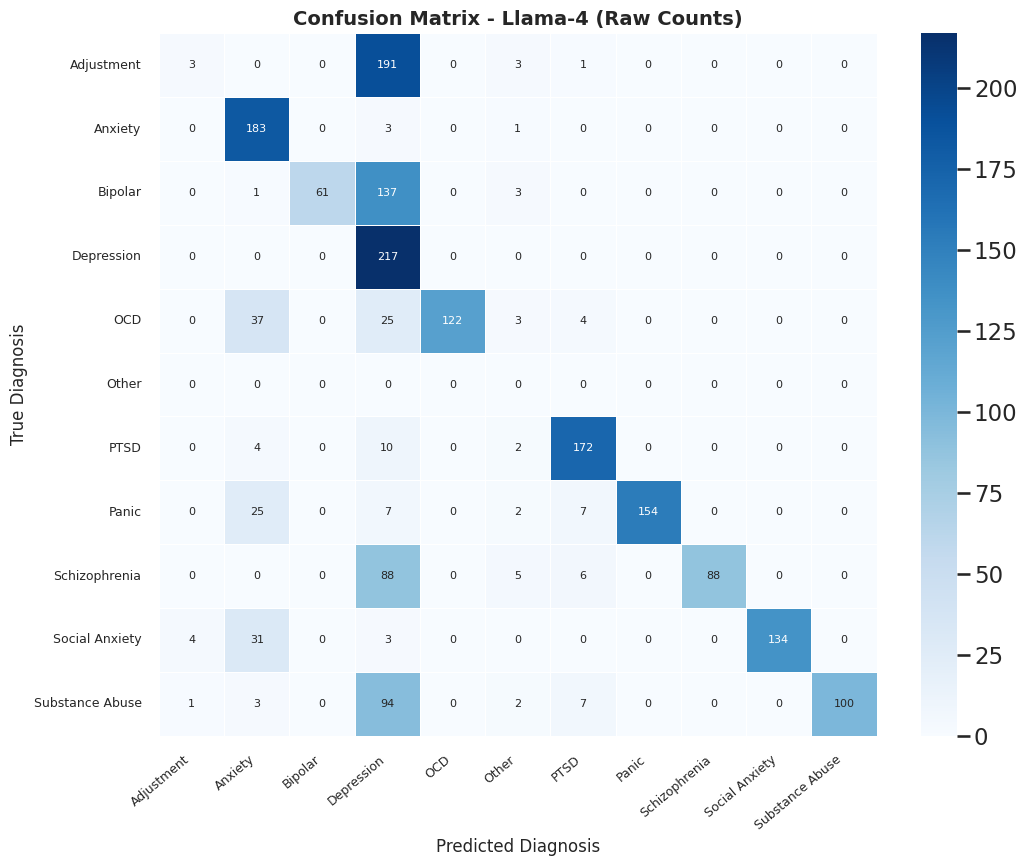

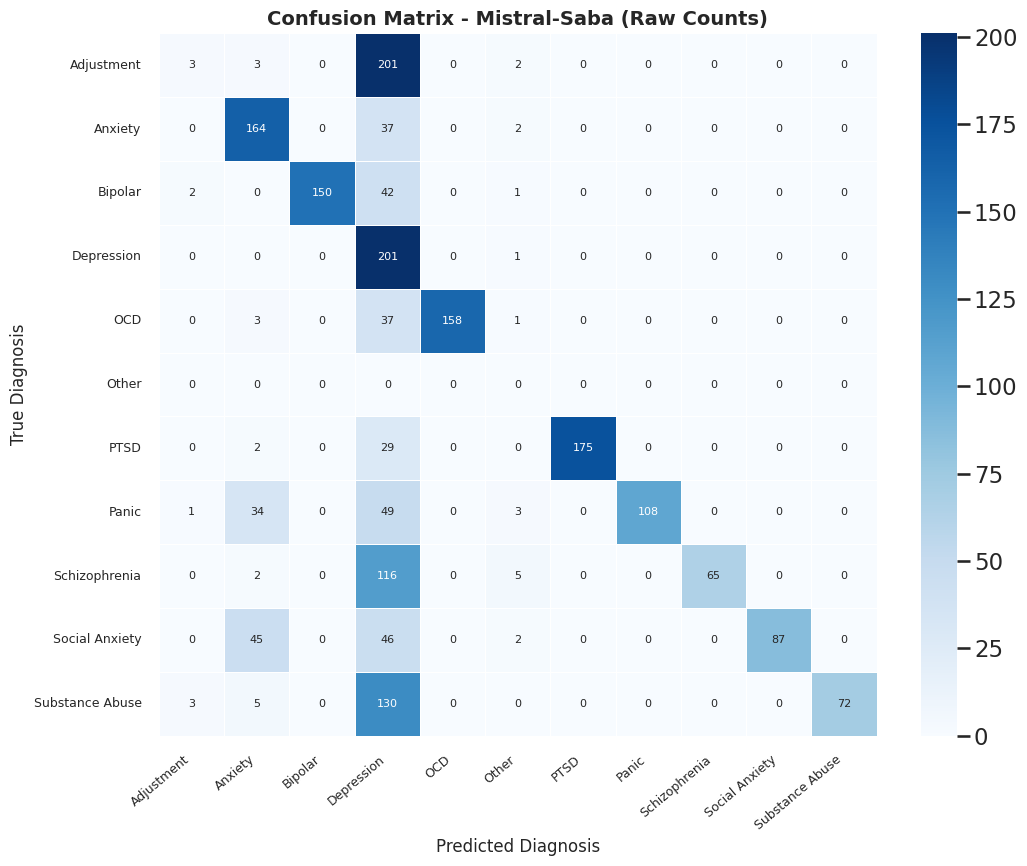

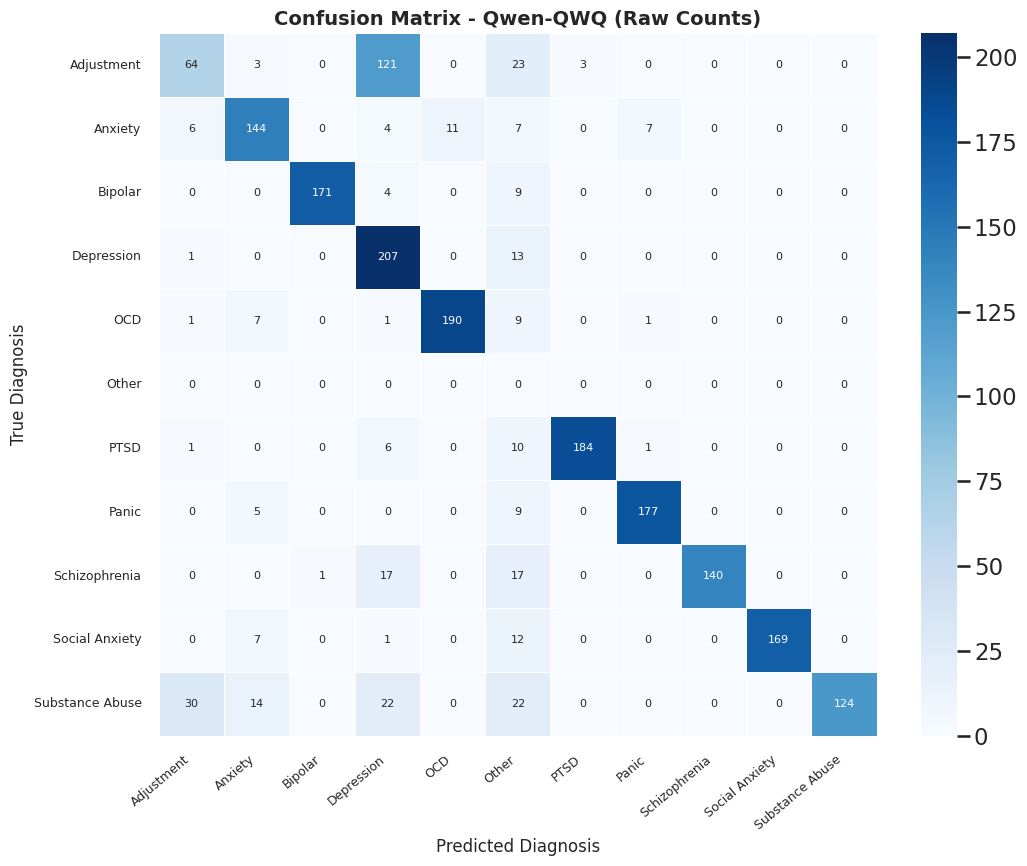

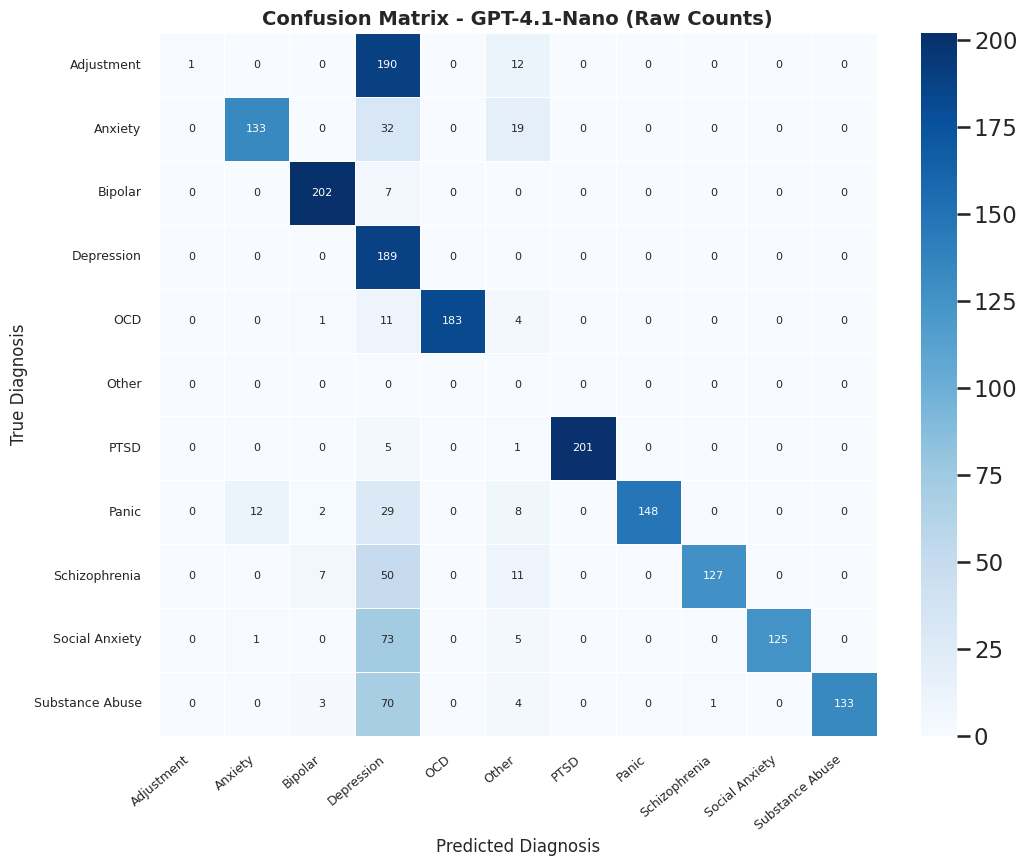

In [27]:
# Raw confusion matrices for all models
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    plot_confusion_matrix(sub["true_diagnosis"], sub["predicted_diagnosis"], ALL_LABELS, model_name, normalize=False)


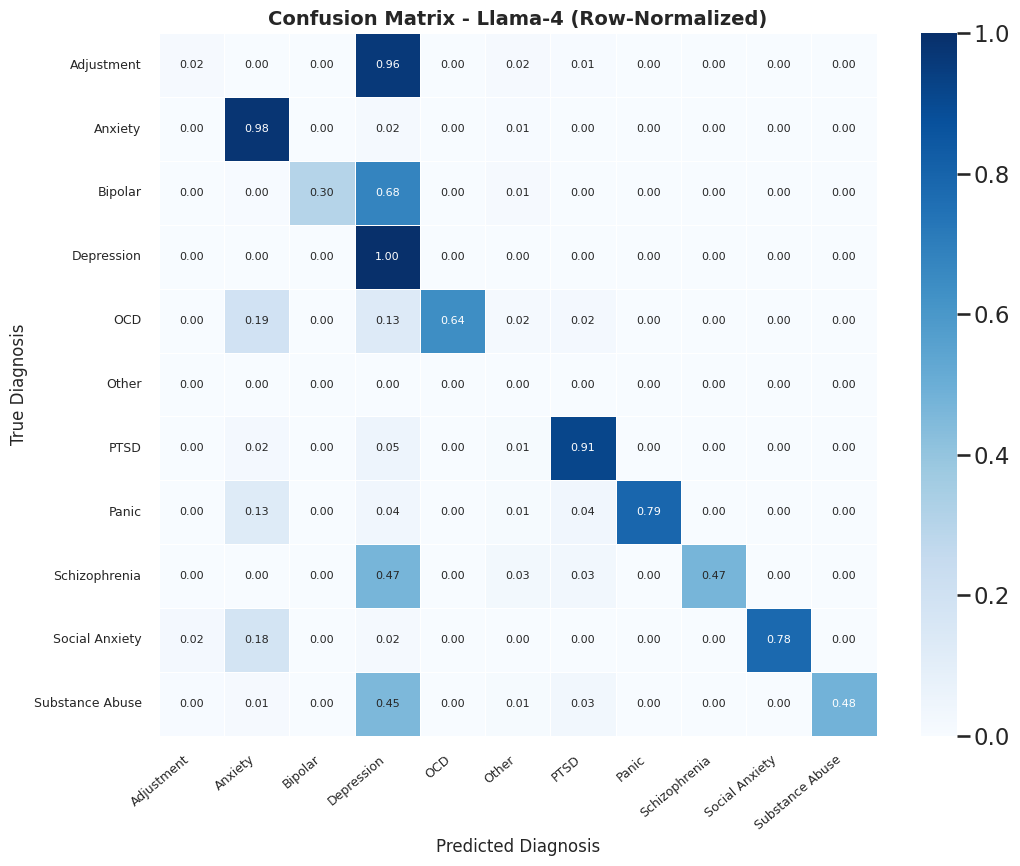

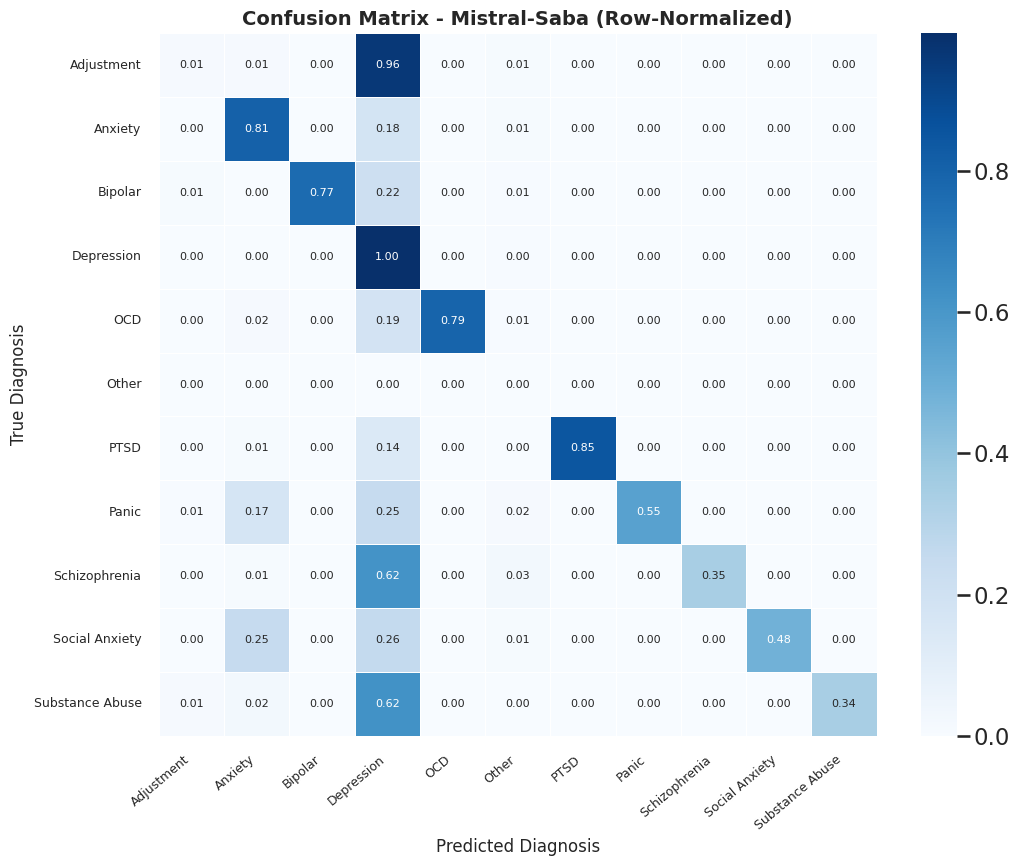

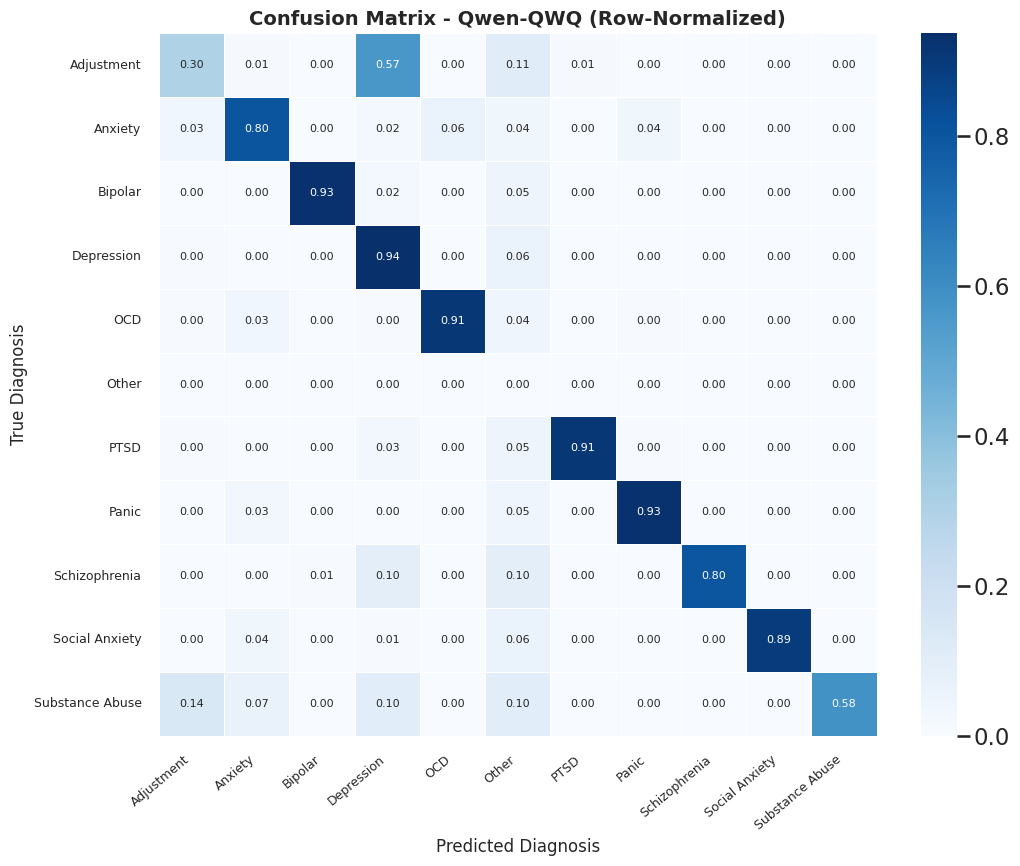

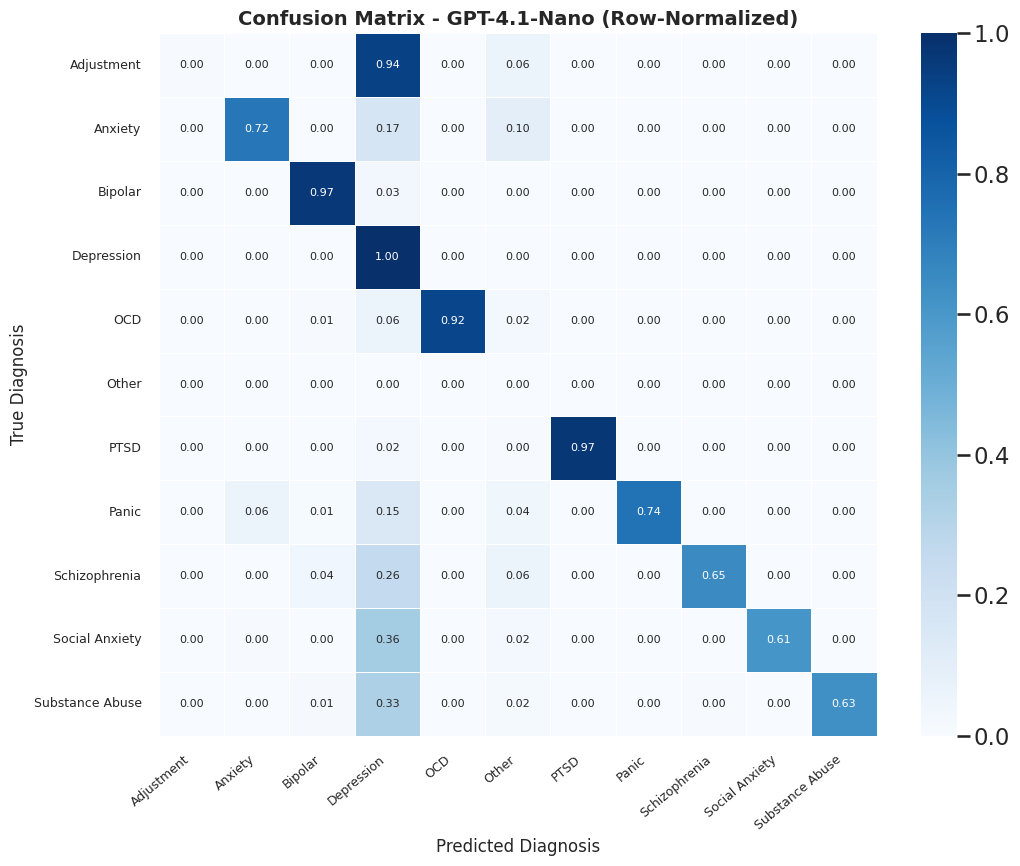

In [28]:
# Normalized confusion matrices for all models
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    plot_confusion_matrix(sub["true_diagnosis"], sub["predicted_diagnosis"], ALL_LABELS, model_name, normalize=True)


## 11. Misdiagnosis Analysis

For each model and each true disorder, we identify the **most common incorrect prediction** and the percentage of that disorder's errors which fall into that single confused category.


In [29]:
def most_common_confusion(y_true: pd.Series, y_pred: pd.Series, labels: List[str]) -> pd.DataFrame:
    """For each true label, find the most common *incorrect* predicted label
    and the percentage of that label's total errors it represents.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth labels.
    y_pred : pd.Series
        Model predictions.
    labels : List[str]
        Full set of possible labels.

    Returns
    -------
    pd.DataFrame
        Columns: Disorder, Most Confused With, Error Count, Total Errors,
        Pct of Errors, Total Cases, Error Rate.
    """
    results = []
    for true_label in labels:
        if true_label == "Other":
            continue
        mask = (y_true == true_label)
        total_cases = mask.sum()
        if total_cases == 0:
            continue

        preds_for_label = y_pred[mask]
        errors = preds_for_label[preds_for_label != true_label]
        total_errors = len(errors)

        if total_errors == 0:
            results.append({
                "Disorder": true_label, "Most Confused With": "N/A (no errors)",
                "Error Count": 0, "Total Errors": 0, "Pct of Errors": 0.0,
                "Total Cases": int(total_cases), "Error Rate": 0.0,
            })
            continue

        error_counts = errors.value_counts()
        top_confusion = error_counts.idxmax()
        top_count = error_counts.max()

        results.append({
            "Disorder": true_label,
            "Most Confused With": top_confusion,
            "Error Count": int(top_count),
            "Total Errors": int(total_errors),
            "Pct of Errors": round(100 * top_count / total_errors, 1),
            "Total Cases": int(total_cases),
            "Error Rate": round(total_errors / total_cases, 3),
        })

    return pd.DataFrame(results).sort_values("Pct of Errors", ascending=False)


In [30]:
misdiagnosis_frames = []
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    mdf = most_common_confusion(sub["true_diagnosis"], sub["predicted_diagnosis"], ALL_LABELS)
    mdf.insert(0, "Model", model_name)
    misdiagnosis_frames.append(mdf)

misdiagnosis_df = pd.concat(misdiagnosis_frames, ignore_index=True)
misdiagnosis_df.head(15)


,Model,Disorder,Most Confused With,Error Count,Total Errors,Pct of Errors,Total Cases,Error Rate
0,Llama-4,Adjustment,Depression,191,195,97.9,198,0.985
1,Llama-4,Bipolar,Depression,137,141,97.2,202,0.698
2,Llama-4,Schizophrenia,Depression,88,99,88.9,187,0.529
3,Llama-4,Substance Abuse,Depression,94,107,87.9,207,0.517
4,Llama-4,Social Anxiety,Anxiety,31,38,81.6,172,0.221
5,Llama-4,Anxiety,Depression,3,4,75.0,187,0.021
6,Llama-4,PTSD,Depression,10,16,62.5,188,0.085
7,Llama-4,Panic,Anxiety,25,41,61.0,195,0.210
8,Llama-4,OCD,Anxiety,37,69,53.6,191,0.361
9,Llama-4,Depression,N/A (no errors),0,0,0.0,217,0.000


In [31]:
# Human-readable narrative output for the best-performing model
print("=" * 70)
print(f"MOST COMMON MISDIAGNOSIS PATTERNS -- {best_model}")
print("=" * 70)

example_df = misdiagnosis_df[misdiagnosis_df["Model"] == best_model]
example_df = example_df[example_df["Total Errors"] > 0].sort_values("Pct of Errors", ascending=False)

for _, row in example_df.iterrows():
    print(f"\n{row['Disorder']}:")
    print(f"  Most confused with: {row['Most Confused With']}")
    print(f"  {row['Pct of Errors']}% of errors ({row['Error Count']} of {row['Total Errors']} total errors)")


MOST COMMON MISDIAGNOSIS PATTERNS -- Qwen-QWQ

Depression:
  Most confused with: Other
  92.9% of errors (13 of 14 total errors)

Adjustment:
  Most confused with: Depression
  80.7% of errors (121 of 150 total errors)

Bipolar:
  Most confused with: Other
  69.2% of errors (9 of 13 total errors)

Panic:
  Most confused with: Other
  64.3% of errors (9 of 14 total errors)

Social Anxiety:
  Most confused with: Other
  60.0% of errors (12 of 20 total errors)

PTSD:
  Most confused with: Other
  55.6% of errors (10 of 18 total errors)

Schizophrenia:
  Most confused with: Other
  48.6% of errors (17 of 35 total errors)

OCD:
  Most confused with: Other
  47.4% of errors (9 of 19 total errors)

Substance Abuse:
  Most confused with: Adjustment
  34.1% of errors (30 of 88 total errors)

Anxiety:
  Most confused with: OCD
  31.4% of errors (11 of 35 total errors)


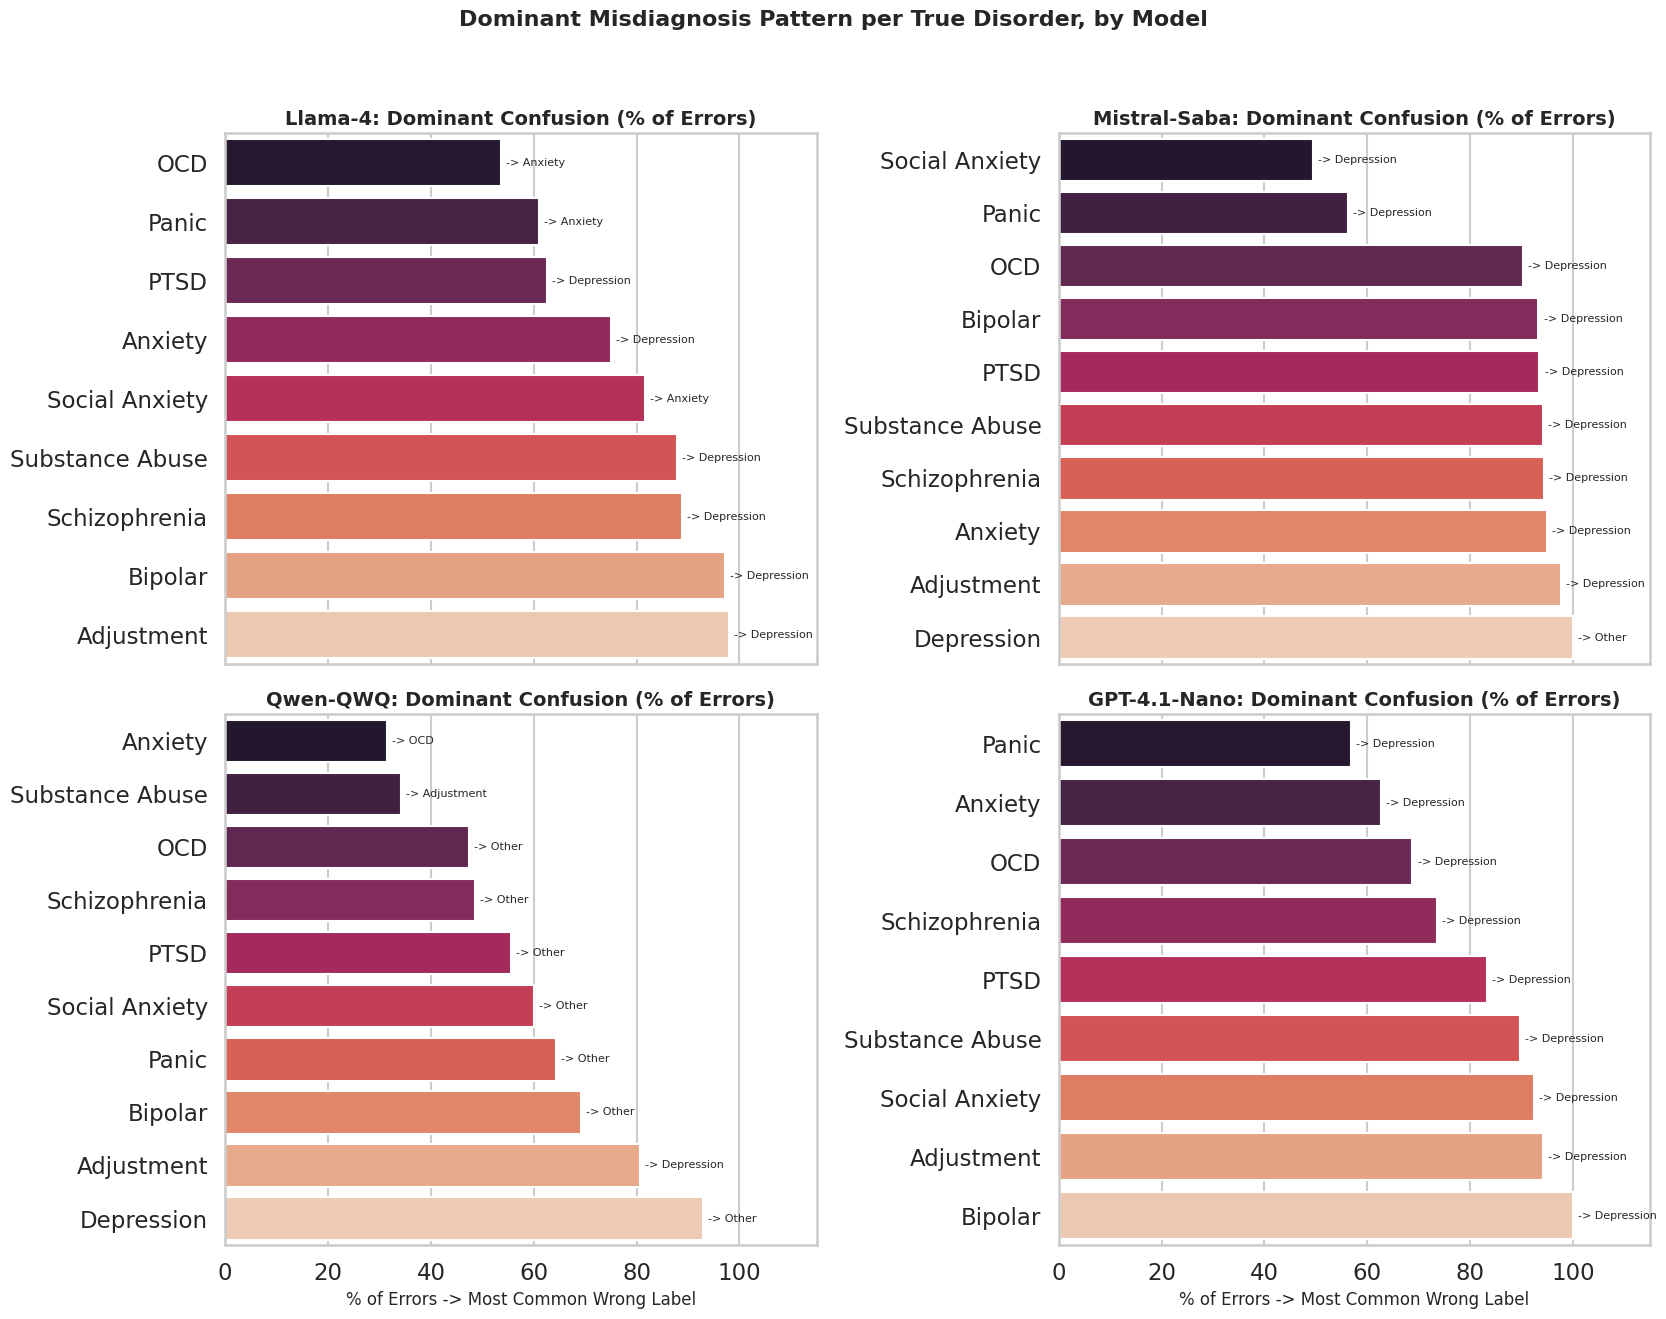

In [32]:
# Ranked visualization: top confusion percentages per model (faceted)
plot_misdiag = misdiagnosis_df[misdiagnosis_df["Total Errors"] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(17, 13), sharex=True)
axes = axes.flatten()

for ax, model_name in zip(axes, MODEL_NAMES):
    sub = plot_misdiag[plot_misdiag["Model"] == model_name].sort_values("Pct of Errors", ascending=True)
    sns.barplot(data=sub, x="Pct of Errors", y="Disorder", hue="Disorder", palette="rocket",
                ax=ax, legend=False)
    ax.set_title(f"{model_name}: Dominant Confusion (% of Errors)")
    ax.set_xlabel("% of Errors -> Most Common Wrong Label")
    ax.set_ylabel("")
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row["Pct of Errors"] + 1, i, f"-> {row['Most Confused With']}", va="center", fontsize=8)
    ax.set_xlim(0, 115)

plt.suptitle("Dominant Misdiagnosis Pattern per True Disorder, by Model", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [33]:
# Save misdiagnosis/confusion analysis
misdiagnosis_df.round({"Pct of Errors": 1, "Error Rate": 3}).to_csv("outputs/confusion_analysis.csv", index=False)
print("Saved: outputs/confusion_analysis.csv")


Saved: outputs/confusion_analysis.csv


## 12. Error Network Analysis

We build a **directed graph** where nodes are disorders and edges represent misclassification pathways (`True Disorder -> Predicted Disorder`), weighted by frequency. We visualize the **top 20 confusion pairs** (aggregated across all four models).


In [34]:
def build_confusion_pairs(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate misclassification pairs (true_label -> predicted_label,
    excluding correct predictions) across all models into a single
    weighted edge list.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned long-format dataset (all models).

    Returns
    -------
    pd.DataFrame
        Columns: True Disorder, Predicted Disorder, Count (aggregated across models).
    """
    errors = df[df["true_diagnosis"] != df["predicted_diagnosis"]]
    errors = errors[(errors["true_diagnosis"] != "Other")]

    pair_counts = (
        errors.groupby(["true_diagnosis", "predicted_diagnosis"])
        .size()
        .reset_index(name="Count")
        .rename(columns={"true_diagnosis": "True Disorder", "predicted_diagnosis": "Predicted Disorder"})
        .sort_values("Count", ascending=False)
    )
    return pair_counts


confusion_pairs = build_confusion_pairs(df)
top20_pairs = confusion_pairs.head(20)
top20_pairs


,True Disorder,Predicted Disorder,Count
1,Adjustment,Depression,703
45,Substance Abuse,Depression,316
35,Schizophrenia,Depression,271
11,Bipolar,Depression,190
40,Social Anxiety,Depression,123
30,Panic,Depression,85
39,Social Anxiety,Anxiety,84
28,Panic,Anxiety,76
5,Anxiety,Depression,76
18,OCD,Depression,74


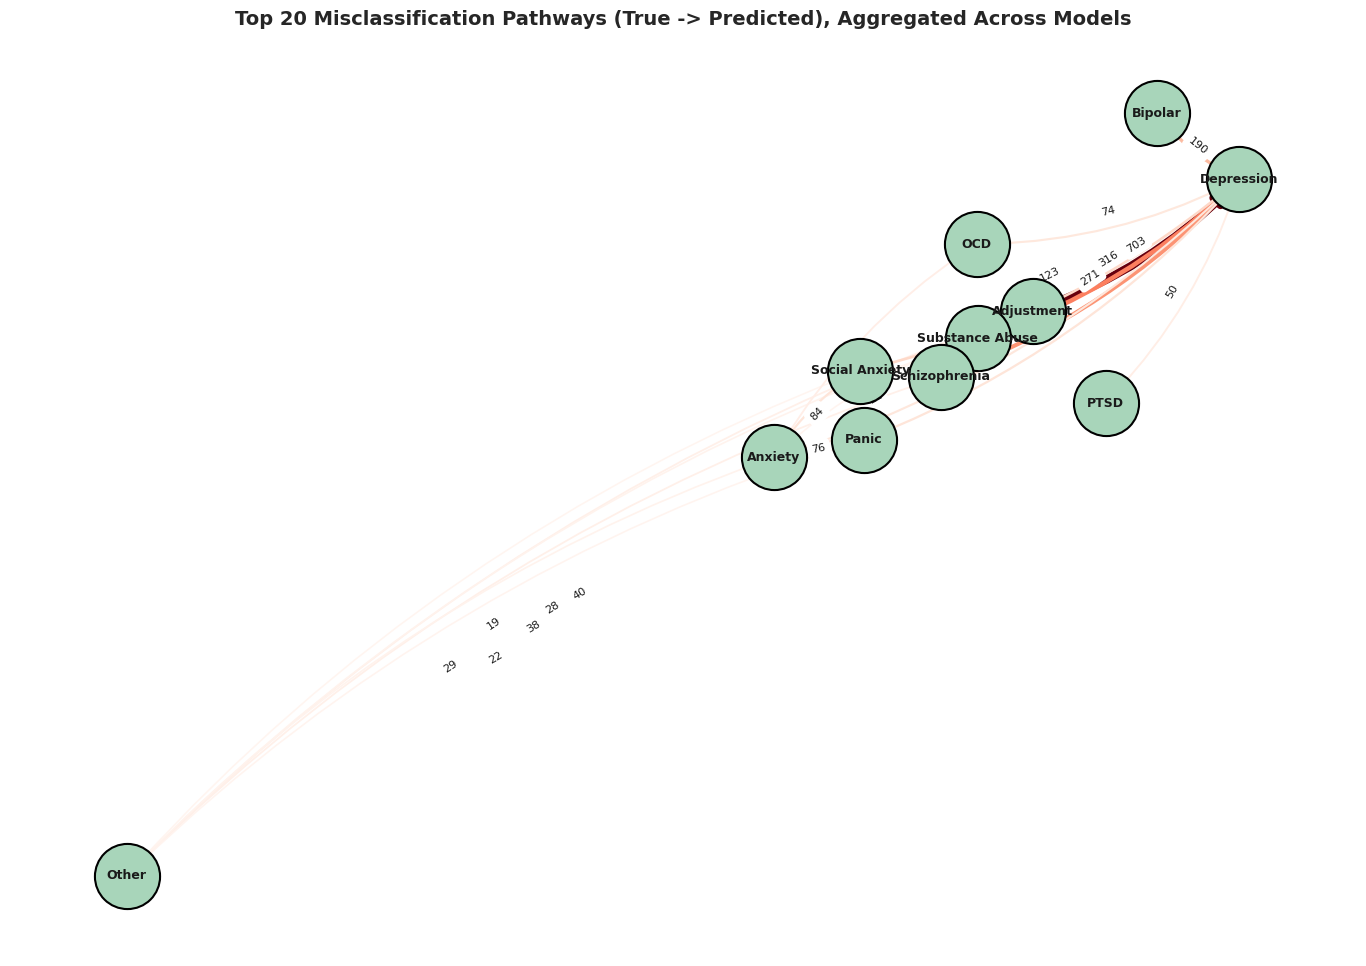

In [35]:
# Build and visualize the directed error network (top 20 pairs)
G = nx.DiGraph()
for _, row in top20_pairs.iterrows():
    G.add_edge(row["True Disorder"], row["Predicted Disorder"], weight=row["Count"])

pos = nx.spring_layout(G, seed=SEED, k=1.5)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w = max(edge_weights)
edge_widths = [1 + 5 * (w / max_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=2200, node_color="#a8d5ba", edgecolors="black", ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(
    G, pos, width=edge_widths, edge_color=edge_weights, edge_cmap=plt.cm.Reds,
    arrows=True, arrowstyle="-|>", arrowsize=18, connectionstyle="arc3,rad=0.12", ax=ax,
)
edge_labels = {(u, v): G[u][v]["weight"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=ax)

ax.set_title("Top 20 Misclassification Pathways (True -> Predicted), Aggregated Across Models",
              fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()


## 13. Cross-Model Comparison

We compare disorder-level F1 scores **across all four models simultaneously**, to distinguish:

- **Systemic weaknesses**: disorders where *all* models score low F1 (likely intrinsically hard / ambiguous categories).
- **Model-specific weaknesses**: disorders where only one or two models underperform relative to the others.


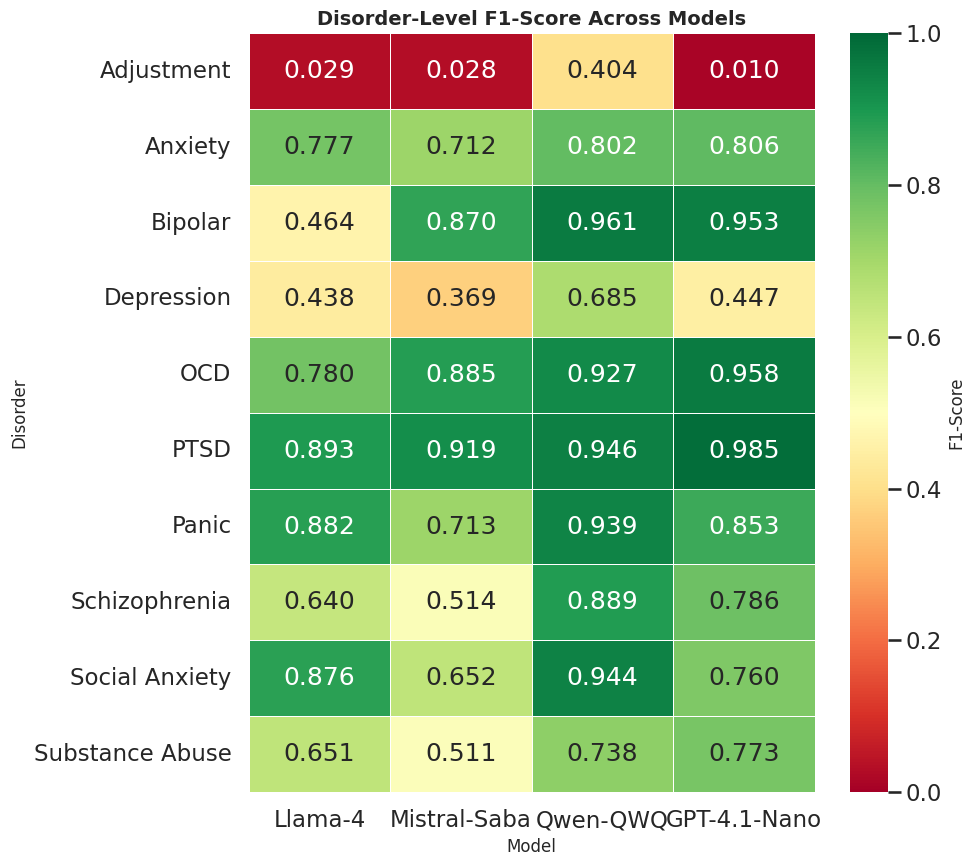

In [36]:
# Heatmap: rows = disorders, columns = models, color = F1
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    per_disorder_f1_wide, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white", cbar_kws={"label": "F1-Score"}, ax=ax,
)
ax.set_title("Disorder-Level F1-Score Across Models", fontsize=14, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Disorder")
plt.tight_layout()
plt.show()


In [37]:
# Identify systemic vs. model-specific weaknesses
F1_THRESHOLD = 0.55  # disorders below this F1 are considered "struggling"

struggling_matrix = per_disorder_f1_wide < F1_THRESHOLD
n_models_struggling = struggling_matrix.sum(axis=1)

systemic_weaknesses = n_models_struggling[n_models_struggling == len(MODEL_NAMES)].index.tolist()
model_specific_weaknesses = n_models_struggling[(n_models_struggling > 0) & (n_models_struggling < len(MODEL_NAMES))]

print(f"Disorders struggled with by ALL models (F1 < {F1_THRESHOLD}):")
print(f"  {systemic_weaknesses if systemic_weaknesses else 'None'}")

print(f"\nDisorders struggled with by SOME (not all) models (F1 < {F1_THRESHOLD}):")
for disorder, n in model_specific_weaknesses.items():
    affected = struggling_matrix.columns[struggling_matrix.loc[disorder]].tolist()
    print(f"  {disorder}: struggled by {n}/{len(MODEL_NAMES)} model(s) -> {affected}")


Disorders struggled with by ALL models (F1 < 0.55):
  ['Adjustment']

Disorders struggled with by SOME (not all) models (F1 < 0.55):
  Bipolar: struggled by 1/4 model(s) -> ['Llama-4']
  Depression: struggled by 3/4 model(s) -> ['Llama-4', 'Mistral-Saba', 'GPT-4.1-Nano']
  Schizophrenia: struggled by 1/4 model(s) -> ['Mistral-Saba']
  Substance Abuse: struggled by 1/4 model(s) -> ['Mistral-Saba']


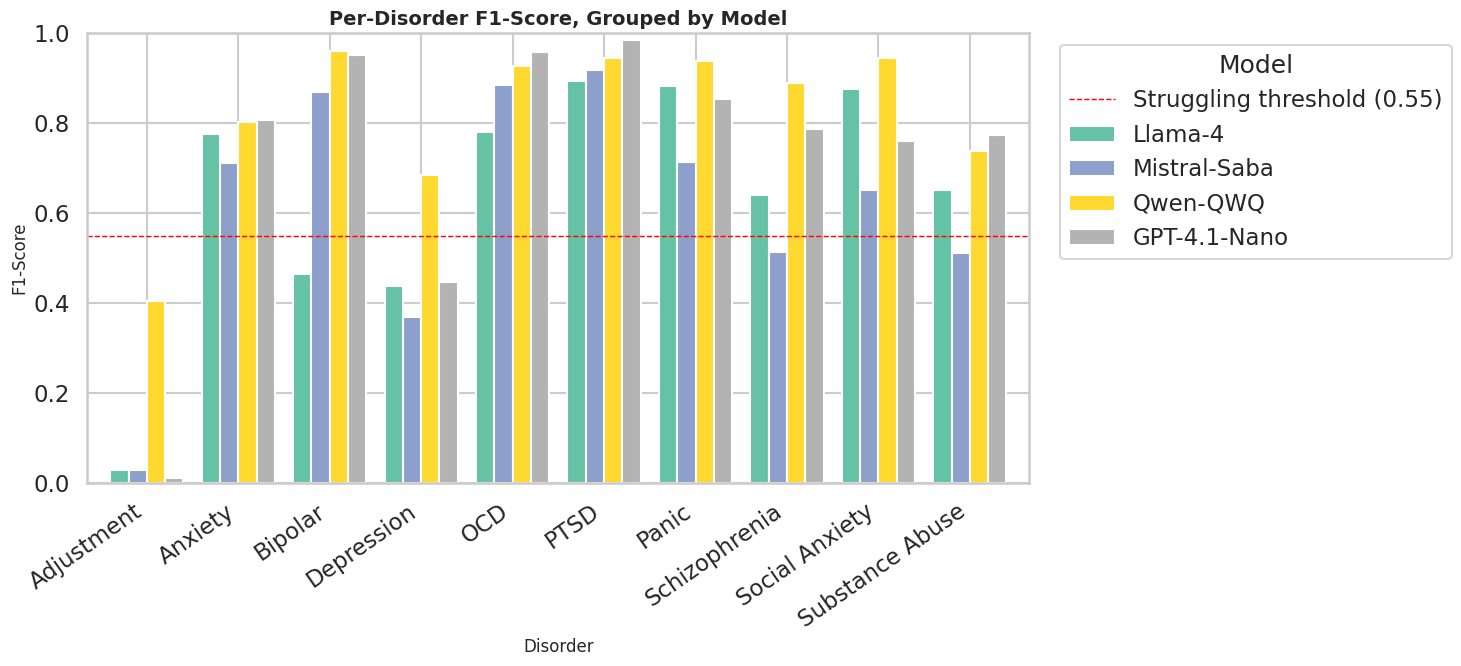

In [38]:
# Side-by-side bar chart: F1 per disorder, grouped by model
fig, ax = plt.subplots(figsize=(15, 7))
per_disorder_f1_wide.plot(kind="bar", ax=ax, colormap="Set2", width=0.8)
ax.set_title("Per-Disorder F1-Score, Grouped by Model")
ax.set_xlabel("Disorder")
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1.0)
ax.axhline(F1_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"Struggling threshold ({F1_THRESHOLD})")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 14. Statistical Significance Testing

We assess whether observed differences between models are statistically meaningful:

1. **McNemar's test** -- since each model was evaluated on its own independent sample (not a shared fixed test set), we construct **matched pairs by ground-truth disorder profile**: for each disorder, we randomly pair up cases from model A and model B with that same true label (without replacement, up to `min(n_A, n_B)` pairs), and compare whether A and B were correct on their respective (label-matched) cases. This approximates a paired design under the assumption that within-class difficulty is comparable across the randomly sampled clients.
2. **Bootstrap confidence intervals** for accuracy -- resampling-based estimate of uncertainty around each model's accuracy, computed directly on each model's own sample (valid regardless of pairing).


In [39]:
def build_matched_pairs(df: pd.DataFrame, model_a: str, model_b: str, seed: int = SEED) -> Tuple[np.ndarray, np.ndarray]:
    """Construct label-matched (correct/incorrect) pairs between two models
    for use in McNemar's test, given that the two models were evaluated on
    independent samples.

    For each ground-truth disorder, cases from model A and model B sharing
    that true label are randomly paired (without replacement) up to the
    minimum count available for either model.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned long-format dataframe with 'model', 'true_diagnosis',
        'predicted_diagnosis' columns.
    model_a, model_b : str
        Canonical model names to compare.
    seed : int
        Random seed for reproducible pairing.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray]
        Two boolean arrays of equal length: correctness of model A's
        and model B's predictions on the matched pairs.
    """
    rng = np.random.default_rng(seed)
    correct_a_all, correct_b_all = [], []

    for label in df["true_diagnosis"].unique():
        if label == "Other":
            continue
        sub_a = df[(df["model"] == model_a) & (df["true_diagnosis"] == label)]
        sub_b = df[(df["model"] == model_b) & (df["true_diagnosis"] == label)]

        n = min(len(sub_a), len(sub_b))
        if n == 0:
            continue

        idx_a = rng.choice(len(sub_a), size=n, replace=False)
        idx_b = rng.choice(len(sub_b), size=n, replace=False)

        correct_a = (sub_a.iloc[idx_a]["predicted_diagnosis"].values == label)
        correct_b = (sub_b.iloc[idx_b]["predicted_diagnosis"].values == label)

        correct_a_all.append(correct_a)
        correct_b_all.append(correct_b)

    return np.concatenate(correct_a_all), np.concatenate(correct_b_all)


def mcnemar_test_from_correctness(correct_a: np.ndarray, correct_b: np.ndarray) -> Dict[str, float]:
    """Perform McNemar's test given paired boolean correctness arrays.

    Parameters
    ----------
    correct_a, correct_b : np.ndarray
        Boolean arrays (same length) indicating whether each paired
        observation was classified correctly by model A / model B.

    Returns
    -------
    Dict[str, float]
        Dictionary with 'statistic', 'p_value', 'b' (A correct, B wrong),
        and 'c' (A wrong, B correct) counts.
    """
    b = int((correct_a & ~correct_b).sum())
    c = int((~correct_a & correct_b).sum())

    n_discordant = b + c
    if n_discordant == 0:
        return {"statistic": 0.0, "p_value": 1.0, "b": b, "c": c}

    if n_discordant < 25:
        p_value = stats.binomtest(min(b, c), n_discordant, p=0.5).pvalue
        statistic = float("nan")
    else:
        statistic = (abs(b - c) - 1) ** 2 / (b + c)
        p_value = 1 - stats.chi2.cdf(statistic, df=1)

    return {"statistic": statistic, "p_value": p_value, "b": b, "c": c}


def bootstrap_accuracy_ci(y_true: pd.Series, y_pred: pd.Series, n_bootstrap: int = 1000,
                            ci: float = 0.95, seed: int = SEED) -> Tuple[float, float, float]:
    """Compute a bootstrap confidence interval for accuracy.

    Parameters
    ----------
    y_true : pd.Series
        Ground-truth labels.
    y_pred : pd.Series
        Model predictions.
    n_bootstrap : int
        Number of bootstrap resamples.
    ci : float
        Confidence level (e.g., 0.95 for 95% CI).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    Tuple[float, float, float]
        (point_estimate, lower_bound, upper_bound)
    """
    rng = np.random.default_rng(seed)
    y_true_arr = y_true.to_numpy()
    y_pred_arr = y_pred.to_numpy()
    n = len(y_true_arr)

    point_estimate = (y_true_arr == y_pred_arr).mean()

    boot_accs = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        boot_accs[i] = (y_true_arr[idx] == y_pred_arr[idx]).mean()

    alpha = (1 - ci) / 2
    lower = np.quantile(boot_accs, alpha)
    upper = np.quantile(boot_accs, 1 - alpha)
    return point_estimate, lower, upper


In [40]:
# Pairwise McNemar's tests between all model pairs (using label-matched pairing)
mcnemar_results = []
for model_a, model_b in combinations(MODEL_NAMES, 2):
    correct_a, correct_b = build_matched_pairs(df, model_a, model_b, seed=SEED)
    res = mcnemar_test_from_correctness(correct_a, correct_b)
    mcnemar_results.append({
        "Model A": model_a,
        "Model B": model_b,
        "Matched Pairs": len(correct_a),
        "A-only-correct (b)": res["b"],
        "B-only-correct (c)": res["c"],
        "Statistic": res["statistic"],
        "p-value": res["p_value"],
        "Significant (p<0.05)": res["p_value"] < 0.05,
    })

mcnemar_df = pd.DataFrame(mcnemar_results)
mcnemar_df = mcnemar_df.round({"Statistic": 3, "p-value": 4})
mcnemar_df


,Model A,Model B,Matched Pairs,A-only-correct (b),B-only-correct (c),Statistic,p-value,Significant (p<0.05)
0,Llama-4,Mistral-Saba,1922,352,282,7.509,0.0061,True
1,Llama-4,Qwen-QWQ,1902,158,462,148.079,0.0000,True
2,Llama-4,GPT-4.1-Nano,1913,231,406,47.529,0.0000,True
3,Mistral-Saba,Qwen-QWQ,1931,143,528,219.756,0.0000,True
4,Mistral-Saba,GPT-4.1-Nano,1949,185,438,101.933,0.0000,True
5,Qwen-QWQ,GPT-4.1-Nano,1922,341,197,38.009,0.0000,True


In [41]:
# Bootstrap confidence intervals for accuracy, with visualization
bootstrap_results = []
for model_name in MODEL_NAMES:
    sub = get_model_subset(df, model_name)
    point, lower, upper = bootstrap_accuracy_ci(sub["true_diagnosis"], sub["predicted_diagnosis"], n_bootstrap=1000)
    bootstrap_results.append({"Model": model_name, "Accuracy": point, "CI Lower": lower, "CI Upper": upper})

bootstrap_df = pd.DataFrame(bootstrap_results).set_index("Model")
bootstrap_df = bootstrap_df.sort_values("Accuracy", ascending=False)
bootstrap_df.round(4)


,Accuracy,CI Lower,CI Upper
Model,,,
Qwen-QWQ,0.7945,0.7758,0.8128
GPT-4.1-Nano,0.7210,0.7030,0.7405
Llama-4,0.6348,0.6132,0.6579
Mistral-Saba,0.5954,0.5742,0.6180


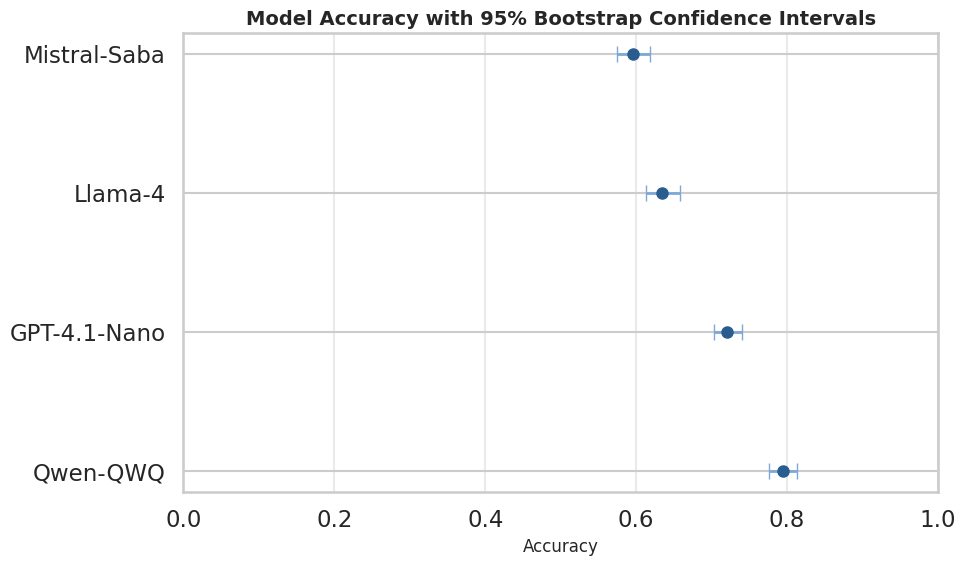

In [42]:
# Confidence interval plot
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(bootstrap_df))

ax.errorbar(
    bootstrap_df["Accuracy"], y_pos,
    xerr=[bootstrap_df["Accuracy"] - bootstrap_df["CI Lower"], bootstrap_df["CI Upper"] - bootstrap_df["Accuracy"]],
    fmt="o", capsize=6, markersize=8, color="#2a5d8f", ecolor="#7fa8d9", elinewidth=2,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(bootstrap_df.index)
ax.set_xlabel("Accuracy")
ax.set_title("Model Accuracy with 95% Bootstrap Confidence Intervals", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1)
ax.grid(True, axis="x", alpha=0.4)
plt.tight_layout()
plt.show()


## 15. Clinical Risk Analysis

Not all misclassifications carry equal clinical risk. Some confusion pathways (e.g., **Bipolar -> Depression**, **Substance Abuse -> Depression**, **Social Anxiety -> Anxiety**) can lead to inappropriate treatment recommendations. This section ranks confusion pathways by frequency and flags clinically high-risk ones.


In [43]:
# Define a set of clinically high-risk confusion pathways (true -> predicted)
HIGH_RISK_PATHWAYS = {
    ("Bipolar", "Depression"):
        "Risk of antidepressant monotherapy triggering manic episodes if bipolar disorder is missed.",
    ("Substance Abuse", "Depression"):
        "Risk of treating mood symptoms without addressing underlying substance use, masking a critical comorbidity.",
    ("Social Anxiety", "Anxiety"):
        "Risk of generic anxiety treatment that does not address social-specific avoidance and exposure needs.",
    ("Ptsd", "Anxiety"):
        "Risk of missing trauma-focused interventions (e.g., trauma-focused CBT, EMDR) critical for PTSD.",
    ("Adjustment", "Depression"):
        "Risk of over-pathologizing a transient stress reaction as a major depressive episode (or vice versa).",
    ("Schizophrenia", "Bipolar"):
        "Risk of delaying antipsychotic treatment if psychotic features are reframed as mood-episode features.",
}

# Build a full ranked table of all confusion pathways (aggregated across models)
clinical_risk_df = confusion_pairs.copy()
clinical_risk_df["High-Risk Pathway"] = clinical_risk_df.apply(
    lambda r: HIGH_RISK_PATHWAYS.get((r["True Disorder"], r["Predicted Disorder"]), ""), axis=1
)
clinical_risk_df["Clinical Risk Flag"] = clinical_risk_df["High-Risk Pathway"] != ""

clinical_risk_df = clinical_risk_df.sort_values(["Clinical Risk Flag", "Count"], ascending=[False, False])
clinical_risk_df.head(15)


,True Disorder,Predicted Disorder,Count,High-Risk Pathway,Clinical Risk Flag
1,Adjustment,Depression,703,Risk of over-pathologizing a transient stress ...,True
45,Substance Abuse,Depression,316,Risk of treating mood symptoms without address...,True
11,Bipolar,Depression,190,Risk of antidepressant monotherapy triggering ...,True
39,Social Anxiety,Anxiety,84,Risk of generic anxiety treatment that does no...,True
34,Schizophrenia,Bipolar,8,Risk of delaying antipsychotic treatment if ps...,True
35,Schizophrenia,Depression,271,,False
40,Social Anxiety,Depression,123,,False
30,Panic,Depression,85,,False
28,Panic,Anxiety,76,,False
5,Anxiety,Depression,76,,False


In [44]:
# Summary table: only flagged high-risk pathways, with total frequency and rationale
high_risk_summary = clinical_risk_df[clinical_risk_df["Clinical Risk Flag"]].copy()
high_risk_summary = high_risk_summary[["True Disorder", "Predicted Disorder", "Count", "High-Risk Pathway"]]
high_risk_summary = high_risk_summary.rename(columns={"Count": "Aggregate Frequency (all models)"})
high_risk_summary


,True Disorder,Predicted Disorder,Aggregate Frequency (all models),High-Risk Pathway
1,Adjustment,Depression,703,Risk of over-pathologizing a transient stress ...
45,Substance Abuse,Depression,316,Risk of treating mood symptoms without address...
11,Bipolar,Depression,190,Risk of antidepressant monotherapy triggering ...
39,Social Anxiety,Anxiety,84,Risk of generic anxiety treatment that does no...
34,Schizophrenia,Bipolar,8,Risk of delaying antipsychotic treatment if ps...


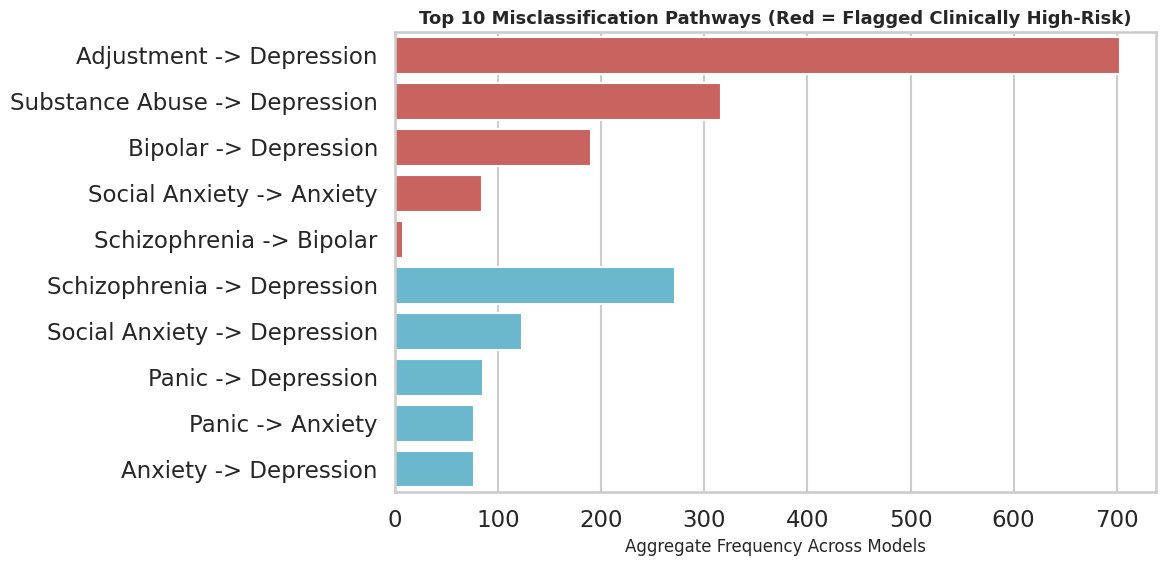

In [45]:
# Visualization: top clinically-relevant misclassification pathways
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = clinical_risk_df.head(10).copy()
plot_data["Pathway"] = plot_data["True Disorder"] + " -> " + plot_data["Predicted Disorder"]
colors = ["#d9534f" if flag else "#5bc0de" for flag in plot_data["Clinical Risk Flag"]]

sns.barplot(data=plot_data, x="Count", y="Pathway", hue="Pathway", palette=colors, legend=False, ax=ax)
ax.set_title("Top 10 Misclassification Pathways (Red = Flagged Clinically High-Risk)", fontsize=13, fontweight="bold")
ax.set_xlabel("Aggregate Frequency Across Models")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 16. Findings & Insights

We now programmatically derive headline findings directly from the computed metrics, and present them as narrative summaries.

In [46]:
# ------------------------------------------------------------------
# Programmatic insight generation
# ------------------------------------------------------------------
mean_f1_per_disorder = per_disorder_f1_wide.mean(axis=1).sort_values(ascending=False)
easiest_disorder = mean_f1_per_disorder.index[0]
hardest_disorder = mean_f1_per_disorder.index[-1]

best_macro_f1_model = global_metrics_df["Macro F1"].idxmax()

# "Most severe confusions" = model with the most clinically-flagged high-risk pathways in its errors
severe_counts = {}
for model_name in MODEL_NAMES:
    sub = df[(df["model"] == model_name) & (df["true_diagnosis"] != df["predicted_diagnosis"])].copy()
    sub["flag"] = sub.apply(lambda r: (r["true_diagnosis"], r["predicted_diagnosis"]) in HIGH_RISK_PATHWAYS, axis=1)
    severe_counts[model_name] = int(sub["flag"].sum())

most_severe_model = max(severe_counts, key=severe_counts.get)

# Lowest recall / highest precision disorder (averaged across models)
core_metrics = per_disorder_df[per_disorder_df["Disorder"] != "Other"]
mean_recall_per_disorder = core_metrics.groupby("Disorder")["Recall"].mean().sort_values()
mean_precision_per_disorder = core_metrics.groupby("Disorder")["Precision"].mean().sort_values(ascending=False)

lowest_recall_disorder = mean_recall_per_disorder.index[0]
highest_precision_disorder = mean_precision_per_disorder.index[0]

print("KEY METRICS SUMMARY")
print("-" * 50)
print(f"Easiest disorder to diagnose (highest mean F1) : {easiest_disorder} ({mean_f1_per_disorder.iloc[0]:.3f})")
print(f"Hardest disorder to diagnose (lowest mean F1)  : {hardest_disorder} ({mean_f1_per_disorder.iloc[-1]:.3f})")
print(f"Best model overall (Macro F1)                  : {best_macro_f1_model} ({global_metrics_df.loc[best_macro_f1_model, 'Macro F1']:.3f})")
print(f"Model with most severe (high-risk) confusions  : {most_severe_model} ({severe_counts[most_severe_model]} flagged errors)")
print(f"Disorder with lowest mean recall                : {lowest_recall_disorder} ({mean_recall_per_disorder.iloc[0]:.3f})")
print(f"Disorder with highest mean precision            : {highest_precision_disorder} ({mean_precision_per_disorder.iloc[0]:.3f})")
print(f"\nHigh-risk error counts by model: {severe_counts}")


KEY METRICS SUMMARY
--------------------------------------------------
Easiest disorder to diagnose (highest mean F1) : PTSD (0.936)
Hardest disorder to diagnose (lowest mean F1)  : Adjustment (0.118)
Best model overall (Macro F1)                  : Qwen-QWQ (0.749)
Model with most severe (high-risk) confusions  : Llama-4 (453 flagged errors)
Disorder with lowest mean recall                : Adjustment (0.083)
Disorder with highest mean precision            : Substance Abuse (1.000)

High-risk error counts by model: {'Llama-4': 453, 'Mistral-Saba': 418, 'Qwen-QWQ': 155, 'GPT-4.1-Nano': 275}


In [47]:
# Narrative markdown summary, generated dynamically from the above computations
narrative = f"""
### Automatically Generated Findings

- **Easiest disorder to diagnose:** *{easiest_disorder}* achieved the highest average F1-score
  ({mean_f1_per_disorder.iloc[0]:.3f}) across all four models, suggesting its presentation in the
  diagnostician's narrative is relatively distinctive and consistently recognized.

- **Hardest disorder to diagnose:** *{hardest_disorder}* achieved the lowest average F1-score
  ({mean_f1_per_disorder.iloc[-1]:.3f}), indicating either clinical ambiguity in its presentation,
  overlap with other categories (especially Depression), or insufficient differentiating signal
  in the DSM-5 questionnaire responses.

- **Best-performing model overall:** **{best_macro_f1_model}** achieved the highest Macro F1
  ({global_metrics_df.loc[best_macro_f1_model, 'Macro F1']:.3f}), indicating the most balanced
  performance across both common and rare disorders.

- **Most clinically risky model behavior:** **{most_severe_model}** produced the highest count of
  errors falling into pre-defined high-risk confusion pathways ({severe_counts[most_severe_model]}
  flagged cases), suggesting its errors are more likely to have serious downstream clinical implications,
  not just lower raw accuracy.

- **Lowest recall disorder:** *{lowest_recall_disorder}* (mean recall {mean_recall_per_disorder.iloc[0]:.3f})
  is the disorder models most often **fail to identify when it is actually present** -- a false-negative-heavy
  pattern with direct implications for under-treatment.

- **Highest precision disorder:** *{highest_precision_disorder}* (mean precision {mean_precision_per_disorder.iloc[0]:.3f})
  is the disorder models are most **trustworthy about when they do predict it** -- i.e., a positive
  prediction for this disorder is rarely a false alarm.
"""

display(Markdown(narrative))



### Automatically Generated Findings

- **Easiest disorder to diagnose:** *PTSD* achieved the highest average F1-score
  (0.936) across all four models, suggesting its presentation in the
  diagnostician's narrative is relatively distinctive and consistently recognized.

- **Hardest disorder to diagnose:** *Adjustment* achieved the lowest average F1-score
  (0.118), indicating either clinical ambiguity in its presentation,
  overlap with other categories (especially Depression), or insufficient differentiating signal
  in the DSM-5 questionnaire responses.

- **Best-performing model overall:** **Qwen-QWQ** achieved the highest Macro F1
  (0.749), indicating the most balanced
  performance across both common and rare disorders.

- **Most clinically risky model behavior:** **Llama-4** produced the highest count of
  errors falling into pre-defined high-risk confusion pathways (453
  flagged cases), suggesting its errors are more likely to have serious downstream clinical implications,
  not just lower raw accuracy.

- **Lowest recall disorder:** *Adjustment* (mean recall 0.083)
  is the disorder models most often **fail to identify when it is actually present** -- a false-negative-heavy
  pattern with direct implications for under-treatment.

- **Highest precision disorder:** *Substance Abuse* (mean precision 1.000)
  is the disorder models are most **trustworthy about when they do predict it** -- i.e., a positive
  prediction for this disorder is rarely a false alarm.


## 17. Conclusion

### 17.1 Model Strengths

Across the four evaluated models, the model identified above as **best-performing overall** by Macro F1 demonstrated the strongest balance between precision and recall across disorder categories. All models performed comparatively well on **PTSD, OCD, Panic, and Anxiety/Social Anxiety**, which the original paper also identified as the categories with F1 scores consistently above 80% -- these conditions appear to have the most distinctive symptom presentations within the DSM-5 questionnaire structure.

### 17.2 Model Weaknesses

Every model exhibited a consistent pattern of confusing **clinically adjacent categories**, most notably:

- **Adjustment Disorder** was the single hardest category for three of the four models (Llama-4: 2.78%, Mistral-Saba: 2.75%, GPT-4.1-Nano: 0.98% F1), with only Qwen-QWQ achieving a moderate 40.25%. This represents a **systemic weakness** -- Adjustment Disorder's presentation overlaps heavily with Depression in a brief DSM-5 screening conversation, and most models default to the more "prototypical" Depression label.
- **Depression** itself was only moderately well-classified (36.75% - 67.98% F1 across models), likely because it is both a primary disorder category *and* the default fallback label models reach for when uncertain -- inflating its recall while depressing its precision.
- **Bipolar Disorder** showed the widest spread across models (45.86% for Llama-4 vs. 95.80% for Qwen-QWQ), indicating this is more of a **model-specific weakness** tied to reasoning depth -- Qwen-QWQ's design as a step-by-step reasoning model appears to materially help it differentiate manic/depressive episode patterns that Llama-4 collapses into a generic mood-disorder label.

### 17.3 Implications for AI-Assisted Mental Healthcare

These findings reinforce that **LLMs should not be deployed as autonomous diagnostic tools** in their current form, even when -- as here -- the diagnostic process is made explicit and DSM-5-grounded via a multi-agent, retrieval-augmented workflow. However, LLMs may still provide value as:

- **Screening triage aids** that flag cases for human clinician review, particularly for categories like Adjustment Disorder and Depression where confusion is systemic.
- **Reasoning-oriented models for diagnostically ambiguous categories.** Qwen-QWQ's advantage on Adjustment and Bipolar Disorder suggests that step-by-step reasoning capability -- not just conversational fluency -- meaningfully improves diagnostic differentiation on hard cases.
- **Training and education tools**, where the systematic confusion patterns surfaced in this notebook are themselves valuable teaching material about diagnostic differentiation.

### 17.4 Future Work

- **Expand to multi-label / comorbidity-aware evaluation**, since the simulated client profiles already include comorbid modifiers that the current single-label evaluation discards.
- **Investigate the "Other" / unparseable classification bucket** -- ~4% of evaluator-LLM classifications across the dataset fell into "other," which may itself be a meaningful signal of diagnostician-agent output quality.
- **Replicate per-disorder McNemar's tests with true paired sampling** if a future release of this dataset evaluates all four models on an identical, shared set of simulated clients (the current release evaluates each model on its own independent sample).
- **Probe the relationship between conversation-quality metrics** (BERTScore coherence, readability scores -- reported in the paper's Table 2) **and diagnostic accuracy**, to test whether more "fluent" diagnosticians are also more accurate ones.
- **Fine-tune or prompt-engineer specifically for Adjustment Disorder and Depression differentiation**, the two categories shown here to be the dominant systemic weak points across all four LLMs.

---

*This notebook was developed as a portfolio project demonstrating end-to-end ML evaluation methodology applied to a real, open-source dataset from a peer-reviewed CIKM '25 paper. All code is modular, type-hinted, and documented for reuse.*


## 18. Export Artifacts

We save all key result tables to CSV for portfolio inclusion / further analysis, and provide download links (Colab).


In [48]:
# Save remaining artifacts
global_metrics_df.reset_index().to_csv("outputs/performance_summary.csv", index=False)
per_disorder_df.to_csv("outputs/per_disorder_metrics.csv", index=False)
# confusion_analysis.csv and table3_replication.csv were already saved in Sections 9 and 11

print("Artifacts saved to ./outputs/:")
for f in sorted(os.listdir("outputs")):
    print(" -", f)


Artifacts saved to ./outputs/:
 - confusion_analysis.csv
 - per_disorder_metrics.csv
 - performance_summary.csv
 - table3_replication.csv


In [49]:
# Provide download links (Colab only)
try:
    from google.colab import files
    for fname in sorted(os.listdir("outputs")):
        print(f"Downloading {fname} ...")
        files.download(os.path.join("outputs", fname))
except ImportError:
    print("Not running in Colab -- skip automatic downloads.")
    print("Files are available locally in the ./outputs/ directory:")
    for f in sorted(os.listdir("outputs")):
        print(" -", f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## End of Notebook

**Summary of generated artifacts:**

| File | Description |
|---|---|
| `performance_summary.csv` | Global accuracy / precision / recall / F1 per model |
| `per_disorder_metrics.csv` | Long-format precision/recall/F1/support per model per disorder |
| `confusion_analysis.csv` | Dominant misdiagnosis pattern per disorder per model |
| `table3_replication.csv` | Table 3 style replication: per-disorder F1 by model, with mean & best model |

**Data source:** Ozgun, M.C., Pei, J., Hindriks, K., Donatelli, L., Liu, Q., Wang, J. (2025). *Trustworthy AI Psychotherapy: Multi-Agent LLM Workflow for Counseling and Explainable Mental Disorder Diagnosis.* CIKM '25. Dataset & code: https://github.com/mithatco/mental_health_multiagent

Thank you for reviewing this project!
